## Setup

### Imports

In [1]:
%load_ext autoreload
%autoreload --print 3

In [2]:
import jax.random as jr
jr.KeyArray = jr.PRNGKey
import shape_norm

from shape_norm.io import loaders
from shape_norm.models import joint
from shape_norm import config
from shape_norm.models import instantiation, setup, pose, morph, util as model_util
from shape_norm import fitting
from shape_norm.fitting import em
from shape_norm.io import alignment, features
from shape_norm.io.armature import Armature
from shape_norm.fitting import methods
from shape_norm.fitting import scans
from shape_norm.pca import fit_with_center, CenteredPCA, PCAData
from shape_norm.io.dataset import PytreeDataset
from shape_norm.io.dataset_refactor import Dataset, SessionMetadata
from shape_norm.models.morph.lowrank_affine import LRAParams, model as lra_model
from shape_norm.viz import styles

from blscale_loader import loader, linear_skeletal as blscale_ls

from collections import defaultdict
from shape_norm.viz import util as vu
from scipy import spatial
import itertools as iit
import matplotlib.colors as mpl_col
from sklearn.linear_model import LogisticRegression
import matplotlib as mpl
import numpy as np
import re
import jax
import jax.numpy as jnp
from pprint import pprint
import numpy.linalg as la
from ruamel.yaml import YAML
import scipy.stats
from pathlib import Path
from cmap import Colormap
from bidict import bidict
import matplotlib as mpl
import joblib as jl
import matplotlib.pyplot as plt
from tqdm import tqdm, trange
import itertools as iit
import pandas as pd
import seaborn as sns


### supporting funcs


#### General supporting funcs

In [3]:
from supporting_funcs.keypoint_data import _bone_lengths, cos, _joint_angles

# _bone_lengths = lambda kpts, arms: jnp.linalg.norm(
#     kpts[..., arms.bones[:, 0], :] - kpts[..., arms.bones[:, 1], :], axis=-1
# )
# cos = lambda a, b, **k: (a * b).sum(**k) / jnp.sqrt((a * a).sum(**k) * (b * b).sum(**k))
# _joint_angles = lambda kpts, joint_kp_ixs: np.array([(180/np.pi) * np.arccos(np.clip(cos(
#     kpts[:, c, :] - kpts[:, p, :],
#     kpts[:, g, :] - kpts[:, p, :],
# axis = -1), -1, 1)) for c, p, g in joint_kp_ixs]).T

In [4]:
# import jax.random as jr

# jr.KeyArray = jr.PRNGKey
# import numpy as np
# import numpy.linalg as la
# from scipy.signal import savgol_filter
# import matplotlib.colors as mpl_col

# # calculus and statistics
# val_and_deriv = lambda x, w=5: (x, savgol_filter(x, w, polyorder=1, deriv=1, axis=0))
# vel_acc = lambda x, w=5: val_and_deriv(  # x, shape (t, ..., spatial)
#     la.norm(savgol_filter(x, w, polyorder=1, deriv=1, axis=0), axis=-1), w=w
# )
# cos = lambda a, b: np.clip(
#     (a * b).sum(axis=-1) / (la.norm(a, axis=-1) * la.norm(b, axis=-1)), -1, 1
# )
# cov = lambda x, y: (x * y).mean(axis=-1) - x.mean(axis=-1) * y.mean(axis=-1)
# corr = lambda a, b: cov(a, b) / np.sqrt(cov(a, a) * cov(b, b))
# coef = lambda a, b: cov(a, b) / cov(a, a)
# windowed_cov = lambda x, y, w: cov(
#     *np.lib.stride_tricks.sliding_window_view(
#         np.pad(
#             np.stack([x, y]),
#             ((0, 0), (int(np.ceil((w - 1) / 2)), int(np.floor((w - 1) / 2)))),
#         ),
#         window_shape=w,
#         axis=1,
#     )
# )

# # skeleton functions
# bone_locations = lambda keypts, armature: np.stack(
#     [
#         keypts[..., armature.bones[i, 1], :] - keypts[..., armature.bones[i, 0], :]
#         for i in range(len(armature.bones))
#     ],
#     axis=-2,
# )
# bone_lengths = lambda keypts, armature: la.norm(
#     bone_locations(keypts, armature), axis=-1
# )
# elevation = (
#     lambda arr: (
#         np.arccos(cos(arr, arr * np.array([1, 1, 0])[None])) * np.sign(arr[:, 2])
#     )
#     * 180
#     / np.pi
# )
# rotation = (
#     lambda arr: (
#         np.arccos(cos(arr, arr * np.array([1, 0, 1])[None])) * np.sign(arr[:, 1])
#     )
#     * 180
#     / np.pi
# )
# short_bone_names = lambda armature: [
#     armature.keypoint_names[int(i)] for i, j in armature.bones
# ]
# long_bone_names = lambda armature: [
#     f"{armature.keypoint_names[int(i)]}-{armature.keypoint_names[int(j)]}"
#     for i, j in armature.bones
# ]


# # model manipulation
# def lra_anchor_poses(params, magnitudes=90):
#     L = params.n_dims

#     if isinstance(magnitudes, (int, float)):
#         magnitudes = magnitudes * np.ones(L)

#     # (n_bodies, n_dims, 1)
#     anchors = (params.offset + params.offset_updates).reshape(params.n_bodies, -1, 1)
#     # (n_bodies, n_dims, n_modes + 1)
#     anchors = np.concatenate(
#         [
#             anchors,
#             anchors + magnitudes[None, None] * (params.modes + params.mode_updates),
#         ],
#         axis=-1,
#     )

#     return anchors


# def lra_induced_anchors(dataset, config, params, magnitudes, n_neighbors):
#     from kpsn.models import util
#     from kpsn.models.morph.lowrank_affine import model

#     anchors = lra_anchor_poses(params, magnitudes)
#     ref_data = dataset.get_session(dataset.ref_session)
#     ref_anchor_diff = (
#         ref_data[..., None]
#         - anchors[None, dataset.session_body_id(dataset.ref_session)]
#     )
#     near_anchors_ix = np.array(
#         [
#             la.norm(ref_anchor_diff[..., j], axis=(-1)).argsort(axis=0)[:n_neighbors]
#             for j in range(anchors.shape[-1])
#         ]
#     )
#     induced_anchors = util.induced_reference_keypoints(
#         dataset,
#         config,
#         model,
#         params,
#         include_reference=True,
#         ref_frames=ref_data[near_anchors_ix].mean(axis=1),
#     )

#     return induced_anchors



# ### plotting


# def plot_mouse_3d(
#     frame,
#     ax,
#     armature,
#     elev,
#     rot,
#     colors=None,
#     bone_n=40,
#     point_size=10,
#     line_size=2,
#     line_colors=None,
#     point_kws={},
#     line_kws={},
#     boundary=True,
#     set_aspect=True,
#     label = None
# ):
#     """all keys in point kws should be present in line kws"""

#     if colors is None:
#         import seaborn as sns

#         colors = mpl_col.to_rgba(sns.color_palette("Blues", 10 + frame.shape[0])[10:])
#     if line_colors is None:
#         line_colors = colors
#     colors = np.array([mpl_col.to_rgba(x) for x in colors])
#     line_colors = np.array([mpl_col.to_rgba(x) for x in line_colors])
#     point_kws = {
#         **dict(
#             linewidths=np.array([0] * armature.n_kpts),
#         ),
#         **point_kws,
#     }
#     line_kws = {
#         **dict(
#             linewidths=np.array([0] * armature.n_kpts),
#         ),
#         **line_kws,
#     }

#     # --- points

#     x, y, z, c, s = [], [], [], [], []
#     x.append(frame[:, 0])
#     y.append(frame[:, 1])
#     z.append(frame[:, 2])
#     c.append(colors)
#     s.append([point_size] * armature.n_kpts)
#     kws = {k: [] for k in point_kws}
#     concat_keys = []
#     for k, v in point_kws.items():
#         if np.array(v).shape[:1] == (armature.n_kpts,):
#             concat_keys.append(k)
#             kws[k].append(v)
#         else:
#             kws[k] = v

#     x = np.concatenate(x)
#     y = np.concatenate(y)
#     z = np.concatenate(z)
#     c = np.concatenate(c)
#     s = np.concatenate(s)
#     for k, v in kws.items():
#         if k in concat_keys:
#             kws[k] = np.concatenate(kws[k])
#     point_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

#     # --- "lines"

#     x, y, z, c, s = [], [], [], [], []
#     kws = {k: [] for k in line_kws}
#     concat_keys = []
#     for i, (ch, pa) in enumerate(armature.bones):
#         x.append(np.linspace(frame[ch, 0], frame[pa, 0], bone_n)[1:-1])
#         y.append(np.linspace(frame[ch, 1], frame[pa, 1], bone_n)[1:-1])
#         z.append(np.linspace(frame[ch, 2], frame[pa, 2], bone_n)[1:-1])
#         c.append(np.full([bone_n - 2, 4], line_colors[ch]))
#         s.append(np.full([bone_n - 2], line_size))
#         for k, v in line_kws.items():
#             if np.array(v).shape[:1] == (armature.n_kpts,):
#                 concat_keys.append(k)
#                 kws[k].append(np.full((bone_n - 2,) + np.array(v).shape[1:], v[ch]))
#             else:
#                 kws[k] = v
#     x = np.concatenate(x)
#     y = np.concatenate(y)
#     z = np.concatenate(z)
#     c = np.concatenate(c)
#     s = np.concatenate(s)
#     for k, v in kws.items():
#         if k in concat_keys:
#             kws[k] = np.concatenate(kws[k])

#     line_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

#     ax.view_init(elev, rot)

#     ax.grid(False)
#     ax.xaxis.pane.fill = False
#     ax.yaxis.pane.fill = False
#     ax.zaxis.pane.fill = False
#     ax.xaxis.set_ticks([])
#     ax.yaxis.set_ticks([])
#     ax.zaxis.set_ticks([])
#     if not boundary:
#         ax.xaxis.pane.set_linewidth(0)
#         ax.yaxis.pane.set_linewidth(0)
#         ax.zaxis.pane.set_linewidth(0)
#         ax.xaxis.line.set_linewidth(0)
#         ax.yaxis.line.set_linewidth(0)
#         ax.zaxis.line.set_linewidth(0)

    
#     # use a.set_box_aspect to make the aspect equal to the ratio of the limits
#     if set_aspect:
#         xrng = np.ptp(ax.get_xlim())
#         yrng = np.ptp(ax.get_ylim())
#         zrng = np.ptp(ax.get_zlim())
#         ax.set_box_aspect([xrng, yrng, zrng])

#     return point_artist, line_artist

#### Dataset supporting funcs

In [2]:
from supporting_funcs.keypoint_data import mouse_data_armature_meta, _with_match, _name_func

# def mouse_data_armature_meta():
#     """Organize metadata on keypoints and skeleton of mouse data."""
#     names = [
#         'shldr', 'back', 'hips', 't_base','t_tip', 'head',
#         'l_ear', 'r_ear', 'nose', 'lr_knee', 'lr_foot',
#         'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot']
#     parents = dict(zip(names, [
#         'back', 'hips', None, 'hips', 't_base', 'shldr',
#         'head', 'head', 'head', 'hips', 'lr_knee',
#         'hips', 'rr_knee', 'shldr', 'shldr']))
#     keypt_ix = lambda name: names.index(name)
#     bones = np.array([(keypt_ix(c), keypt_ix(p)) for c, p in parents.items() if p])
#     root = keypt_ix("shldr")
#     bones = blscale_ls.reroot(bones, root)
#     bones = bones[np.argsort(bones[:, 0])]
#     return names, parents, bones, root

# _with_match = lambda test, pattern, f: f(m) if (m := re.search(pattern, test)) else None
# _name_func = lambda path, *a: _with_match(
#     path, r"(?:/.*)+/\d{2}_\d{2}_\d{2}_(\d+wk_m\d+)\.npy",
#     lambda m: f"{m.group(1)}")


# ---- deprecated

# def load_all_mouse_sessions(age_whitelist = None):
#     data_root = '../../../../data_explore/data'

#     # Create mapping of session names (ie 3wk_m0) to keypoint data paths

#     modata_npy_name_func = (lambda path, *a:
#         match.group(1) if ((match := re.search(r"\d{2}_\d{2}_\d{2}_(\d+wk_m\d+)\.npy", path)) is not None) else None)
#     session_paths = dict(filter(lambda x: x[0] is not None, [(modata_npy_name_func(m), str(Path(data_root) / m)) for m in os.listdir(data_root)]))
#     # throw out 9-12 week
#     session_ages = {s: s.split('_')[0].strip('wk') for s in session_paths}
#     ages = set(session_ages.values())
#     if age_whitelist is not None:
#         ages = list(filter(lambda x: x in age_whitelist, ages))
#     session_paths = {s: p for s, p in session_paths.items() if session_ages[s] in ages}
#     session_bodies = {s: f'body-{session_ages[s]}wk' for s in session_paths}
#     names, parents, _, _ = mouse_data_armature_meta()

#     age_dates =  {
#         "3" : "10_11_22",
#         "5" : "10_24_22",
#         "7" : "10_24_22",
#         "24": "11_03_22",
#         "52" : "11_03_22",
#         "72" : "10_14_22",
#     }

#     print("sessions:", session_paths.keys())

#     sesssion_kps = {
#         s: np.load(p) for s, p in session_paths.items()
#     }

#     project_config_kws = {
#         "session_names": list(sesssion_kps.keys()),
#         "bodies": session_bodies,
#         "keypoint_names": names,
#         "keypoint_parents": parents,
#     }

#     return project_config_kws, sesssion_kps

#### plotting supporting funcs

In [6]:
from supporting_funcs.plotting import getc, plot_mouse_3d, plotdrop

# def getc(spec):
#     try:
#         from cmap import Colormap, Color
#         try:
#             return Color(spec)
#         except ValueError as e:
#             stop = spec.split(':')[-1]
#             if stop.startswith('.'):
#                 stop = float(stop)
#             else:
#                 stop = int(stop)
#             cm = Colormap(':'.join(spec.split(':')[:-1]))
#             return cm(stop)
#     except ImportError:
#         return spec

# def plot_mouse_3d(
#     frame,
#     ax,
#     armature,
#     elev,
#     rot,
#     colors=None,
#     bone_n=40,
#     point_size=10,
#     line_size=2,
#     line_colors=None,
#     point_kws={},
#     line_kws={},
#     boundary=True,
#     set_aspect=True,
#     label = None
# ):
#     """all keys in point kws should be present in line kws"""

#     if colors is None:
#         import seaborn as sns

#         colors = mpl_col.to_rgba(sns.color_palette("Blues", 10 + frame.shape[0])[10:])
#     if line_colors is None:
#         line_colors = colors
#     colors = np.array([mpl_col.to_rgba(x) for x in colors])
#     line_colors = np.array([mpl_col.to_rgba(x) for x in line_colors])
#     point_kws = {
#         **dict(
#             linewidths=np.array([0] * armature.n_kpts),
#         ),
#         **point_kws,
#     }
#     line_kws = {
#         **dict(
#             linewidths=np.array([0] * armature.n_kpts),
#         ),
#         **line_kws,
#     }

#     # --- points

#     x, y, z, c, s = [], [], [], [], []
#     x.append(frame[:, 0])
#     y.append(frame[:, 1])
#     z.append(frame[:, 2])
#     c.append(colors)
#     s.append([point_size] * armature.n_kpts)
#     kws = {k: [] for k in point_kws}
#     concat_keys = []
#     for k, v in point_kws.items():
#         if np.array(v).shape[:1] == (armature.n_kpts,):
#             concat_keys.append(k)
#             kws[k].append(v)
#         else:
#             kws[k] = v

#     x = np.concatenate(x)
#     y = np.concatenate(y)
#     z = np.concatenate(z)
#     c = np.concatenate(c)
#     s = np.concatenate(s)
#     for k, v in kws.items():
#         if k in concat_keys:
#             kws[k] = np.concatenate(kws[k])
#     point_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

#     # --- "lines"

#     x, y, z, c, s = [], [], [], [], []
#     kws = {k: [] for k in line_kws}
#     concat_keys = []
#     for i, (ch, pa) in enumerate(armature.bones):
#         x.append(np.linspace(frame[ch, 0], frame[pa, 0], bone_n)[1:-1])
#         y.append(np.linspace(frame[ch, 1], frame[pa, 1], bone_n)[1:-1])
#         z.append(np.linspace(frame[ch, 2], frame[pa, 2], bone_n)[1:-1])
#         c.append(np.full([bone_n - 2, 4], line_colors[ch]))
#         s.append(np.full([bone_n - 2], line_size))
#         for k, v in line_kws.items():
#             if np.array(v).shape[:1] == (armature.n_kpts,):
#                 concat_keys.append(k)
#                 kws[k].append(np.full((bone_n - 2,) + np.array(v).shape[1:], v[ch]))
#             else:
#                 kws[k] = v
#     x = np.concatenate(x)
#     y = np.concatenate(y)
#     z = np.concatenate(z)
#     c = np.concatenate(c)
#     s = np.concatenate(s)
#     for k, v in kws.items():
#         if k in concat_keys:
#             kws[k] = np.concatenate(kws[k])

#     line_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

#     ax.view_init(elev, rot)

#     ax.grid(False)
#     ax.xaxis.pane.fill = False
#     ax.yaxis.pane.fill = False
#     ax.zaxis.pane.fill = False
#     ax.xaxis.set_ticks([])
#     ax.yaxis.set_ticks([])
#     ax.zaxis.set_ticks([])
#     if not boundary:
#         ax.xaxis.pane.set_linewidth(0)
#         ax.yaxis.pane.set_linewidth(0)
#         ax.zaxis.pane.set_linewidth(0)
#         ax.xaxis.line.set_linewidth(0)
#         ax.yaxis.line.set_linewidth(0)
#         ax.zaxis.line.set_linewidth(0)

    
#     # use a.set_box_aspect to make the aspect equal to the ratio of the limits
#     if set_aspect:
#         xrng = np.ptp(ax.get_xlim())
#         yrng = np.ptp(ax.get_ylim())
#         zrng = np.ptp(ax.get_zlim())
#         ax.set_box_aspect([xrng, yrng, zrng])

#     return point_artist, line_artist


# drop_kws = lambda c, ps, ls, arms, override: {**dict(
#     armature = arms,
#     elev = 30, 
#     rot = -60,
#     colors = np.array([c] * arms.n_kpts),
#     point_size = ps,
#     line_size = ls,
#     boundary=False,
# ), **override}
# dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[:, 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
# dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[:, 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
# dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[:, 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
# plotdrop = lambda f, a, c, sm=1, lsm=1, shad=True, dropax=None, shadx=True, shady=True, shadz=True, arms=None, override={}: [
#     plot_mouse_3d(f, a, **drop_kws(c, sm * 15, 1.5 * lsm, arms, override))
#     ] + [
#     dropax := dropax if dropax is not None else a,
#     ] + ([
#     plot_mouse_3d(dropz(f, -7), dropax, **drop_kws('.9', sm * 7, 1 * lsm, arms, {})) if shadz else None,
#     plot_mouse_3d(dropy(f, 10), dropax, **drop_kws('.9', sm * 7, 1 * lsm, arms, {})) if shady else None,
#     plot_mouse_3d(dropx(f, -7), dropax, **drop_kws('.9', sm * 7, 1 * lsm, arms, {})) if shadx else None,
# ] if shad else [])

#### Dataset functions

In [7]:
from supporting_funcs.keypoint_data import _with_match, _name_func, full_ontogeny_data_aligned, full_ontogeny_data

# _with_match = lambda test, pattern, f: f(m) if (m := re.search(pattern, test)) else None
# _name_func = lambda path, *a: _with_match(
#     path, r"(?:/.*)+/\d{2}_\d{2}_\d{2}_(\d+wk_m\d+)\.npy",
#     lambda m: f"{m.group(1)}")

# def full_ontogeny_data(data_dir, session_filter=None, ref_session=None):
#     _sources = dict(map(lambda x: (_name_func(str(x)),) * 2, data_dir.glob(f"*.npy")))
#     if session_filter is not None:
#         _sources = {k: v for k, v in _sources.items() if session_filter(k)}
#     ont_keypoints, _ = loader.from_sources_dict(
#         data_dir,
#         _sources,
#         extension='.npy',
#         name_func=_name_func,
#     )
#     names, parents, _, _ = mouse_data_armature_meta()

#     if ref_session is None:
#         ref_session = list(ont_keypoints.keys())[0]

#     project_config_kws = {
#         "session_names": ont_keypoints.keys(),
#         "bodies": {s: f'b-{s}' for s in ont_keypoints},
#         "ref_session": ref_session,
#         "keypoint_names": names,
#         "keypoint_parents": parents,
#     }

#     return project_config_kws, ont_keypoints

# def full_ontogeny_data_aligned(data_dir, session_filter=None, use_keypoints=None, scale_ntt=False):
#     project_config_kws, ont_keypoints = full_ontogeny_data(data_dir, session_filter)
#     if use_keypoints is None:
#         use_keypoints = project_config_kws['keypoint_names']
#     dataset = loaders.arrays.from_arrays(ont_keypoints, dict(
#         type='arrays',
#         subsample=None,
#         subsample_to=None,
#         ref_session=project_config_kws['ref_session'],
#         sessions={s: dict(body=b) for s, b in project_config_kws['bodies'].items()},
#         keypoint_names=project_config_kws['keypoint_names'],
#         use_keypoints=use_keypoints,
#         anterior=None,
#         posterior=None,
#         invert_axes=None,
#     ))
#     aligned, align_inv = alignment.align(dataset, dict(
#         type='sagittal',
#         origin='hips',
#         anterior='head',
#         rescale=scale_ntt,
#         rescale_mode='session',
#     ))
#     return aligned, dataset, align_inv
    

#### Plotting funcs (deprecated)

In [8]:
# def getc(spec):
#     try:
#         from cmap import Colormap, Color
#         try:
#             return Color(spec)
#         except ValueError as e:
#             stop = spec.split(':')[-1]
#             if stop.startswith('.'):
#                 stop = float(stop)
#             else:
#                 stop = int(stop)
#             cm = Colormap(':'.join(spec.split(':')[:-1]))
#             return cm(stop)
#     except ImportError:
#         return spec
    
    
# plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
# age_pal = {k: getc(c) for k, c in plot_meta['colors']['age'].items()}
# bhv_pal = {k: getc(c) for k, c in plot_meta['colors']['bhv'].items()}

_plotdrop_kws = lambda c, ps, ls, arms: dict(
    armature = arms,
    elev = 30, 
    rot = -70,
    colors = np.array([c] * arms.n_kpts) if np.array(c).ndim < 2 else c,
    point_size = ps,
    line_size = ls,
    boundary=False,
)
_dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[..., 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
_dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[..., 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
_dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[..., 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
_plotdrop = lambda f, a, c, sm=1, lsm=1, shad=True, dropax=None, shad_x = True, shad_y=True, shad_z=True, arms=None, **kws: [
    plot_mouse_3d(f, a, **{**_plotdrop_kws(c, sm * 15, 1.5 * lsm, arms), **kws})
    ] + [
    dropax := dropax if dropax is not None else a,
    ] + ([
    plot_mouse_3d(_dropz(f, -7), dropax, **_plotdrop_kws('.9', sm * 7, 1 * lsm, arms)) if shad_z else None,
    plot_mouse_3d(_dropy(f, 10), dropax, **_plotdrop_kws('.9', sm * 7, 1 * lsm, arms)) if shad_y else None,
    plot_mouse_3d(_dropx(f, -7), dropax, **_plotdrop_kws('.9', sm * 7, 1 * lsm, arms)) if shad_x else None,
] if shad else [])

#### Linear classifier supporting funcs

In [9]:
from supporting_funcs.classifiers import (
    indiv_holdout,
    frame_holdout,
    pairwise_group_acc,
    allway_group_acc,
    pairwise_framewise_acc,
    named_group_pairwise_framewise_acc,
    calculate_feat_scaled_kp_normed,
    calc_all_scores,
    calc_indiv_filtered_scores,
    classif_strip,
    classif_strip_points,
)

# def indiv_holdout(feats, groups, seed, shuffle):
#     rng = np.random.default_rng(seed)
#     feat_val = []
#     feat_trn = []
#     tgt_val = []
#     tgt_trn = []
#     tgt_keys = dict(zip(groups.keys(), range(len(groups))))
#     for grp_key, grp in groups.items():
#         holdout = rng.integers(len(grp))
#         feat_val.append(feats[grp[holdout]])
#         feat_trn.extend([feats[s] for i, s in enumerate(grp) if i != holdout])
#         lens = [len(feats[s]) for s in grp]
#         tgt_val.append(np.full(lens[holdout], tgt_keys[grp_key]))
#         tgt_trn.extend([np.full(l, tgt_keys[grp_key]) for i, l in enumerate(lens) if i != holdout])
#     feat_val = np.concatenate(feat_val, axis = 0)
#     feat_trn = np.concatenate(feat_trn, axis = 0)
#     tgt_val = np.concatenate(tgt_val, axis = 0)
#     tgt_trn = np.concatenate(tgt_trn, axis = 0)
#     if shuffle:
#         tgt_trn = rng.permutation(tgt_trn)
#     return feat_trn, feat_val, tgt_trn, tgt_val

# def frame_holdout(feats, groups, seed, shuffle, train_pct = 0.5):
#     if isinstance(seed, int):
#         rng = np.random.default_rng(seed)
#     else:
#         rng = seed
#     feat_val = []
#     feat_trn = []
#     tgt_val = []
#     tgt_trn = []
#     tgt_keys = dict(zip(groups.keys(), range(len(groups))))
#     for grp_key, grp in groups.items():
#         for s in grp:
#             x = feats[s]
#             trn, val = np.split(rng.permutation(len(x)), [int(train_pct * len(x))])
#             feat_trn.append(x[trn])
#             feat_val.append(x[val])
#             tgt_trn.append(np.full(len(trn), tgt_keys[grp_key]))
#             tgt_val.append(np.full(len(val), tgt_keys[grp_key]))
#     feat_val = np.concatenate(feat_val, axis = 0)
#     feat_trn = np.concatenate(feat_trn, axis = 0)
#     tgt_val = np.concatenate(tgt_val, axis = 0)
#     tgt_trn = np.concatenate(tgt_trn, axis = 0)
#     if shuffle:
#         tgt_trn = rng.permutation(tgt_trn)
#     return feat_trn, feat_val, tgt_trn, tgt_val

# def pairwise_group_acc(feats, groups, ref, nonref, n_iter = 40):
#     scores = {a: [] for a in nonref}
#     scores_null = {a: [] for a in nonref}
#     for is_null, scores_dict in enumerate([scores, scores_null]):
#         for nonref_age in tqdm(nonref):
#             for seed in range(n_iter):
#                 xt, xv, yt, yv = indiv_holdout(
#                     feats,
#                     {ref: groups[ref], nonref_age: groups[nonref_age]},
#                     seed,
#                     shuffle = is_null
#                 )
#                 model = LogisticRegression(max_iter=1000, class_weight="balanced")
#                 scores_dict[nonref_age].append(model.fit(xt, yt).score(xv, yv))
#     return scores, scores_null

# def allway_group_acc(feats, groups, n_iter = 40, subsample = 1, clf_kws = {}, prescale = False):
#     scores_list = [[], []]
#     for is_null in range(2):
#         for seed in tqdm.trange(n_iter):
#             xt, xv, yt, yv = indiv_holdout(
#                 {k: v[::subsample] for k, v in feats.items()},
#                 groups,
#                 seed,
#                 shuffle = is_null
#             )
#             if prescale:
#                 m, sd = xt.mean(axis = 0), xt.std(axis = 0)
#                 xt = (xt - m) / sd
#                 xv = (xv - m) / sd
#             model = LogisticRegression(**{**dict(max_iter=1000, class_weight="balanced"), **clf_kws})
#             scores_list[is_null].append(model.fit(xt, yt).score(xv, yv))
#     return scores_list

# def pairwise_framewise_acc(feats, groups, n_iter = 1, across_mode = 'none', rng = None):
#     """
#     Returns
#     -------
#     across_group : list
#         Frames taken from sessions in different groups forming positive and
#         negative example sets.
#     across_group_null : list
#         As in `across_group` but with shuffled labels.
#     within_group : list
#         Frames from different sessions within the same group forming positive
#         and negative example sets.
#     within_session : list
#         Sets of frames taken from within the same session forming positive and
#         negative example sets.
#     """
#     scores_list = [[], [], [], []]
#     combos = list(iit.combinations(groups.keys(), 2)) + [(k, k) for k in groups.keys()]
#     if rng is None:
#         rng = np.random.default_rng()
#     for g1, g2 in tqdm(combos):
#         within_group = g1 == g2
#         if across_mode == 'across-only' and within_group:
#             continue
#         if across_mode == 'within-only' and not within_group:
#             continue
#         for is_null in range(2 if not within_group else 1):
#             for i, (s1, s2) in enumerate(iit.product(groups[g1], groups[g2])):
#                 within_animal = s1 == s2
#                 for j in range(n_iter):
#                     xt, xv, yt, yv = frame_holdout(
#                         feats,
#                         {'s1': [s1], 's2': [s2]},
#                         rng,
#                         shuffle = is_null
#                     )
#                     # print(np.unique(yt, return_counts=True), np.unique(yv, return_counts=True))
#                     model = LogisticRegression(max_iter=1000, class_weight="balanced")
#                     score_ix = 3 if within_animal else (2 if within_group else is_null)
#                     scores_list[score_ix].append(model.fit(xt, yt).score(xv, yv))
#     return scores_list

# def named_group_pairwise_framewise_acc(feats, groups, n_iter = 1, across_mode = 'none', rng = None):
#     """
#     Returns
#     -------
#     across_group : dict
#         Frames taken from sessions in different groups forming positive and
#         negative example sets.
#     across_group_null : dict
#         As in `across_group` but with shuffled labels.
#     within_group : dict
#         Frames from different sessions within the same group forming positive
#         and negative example sets.
#     within_session : dict
#         Sets of frames taken from within the same session forming positive and
#         negative example sets.
#     """
#     scores_list = [defaultdict(list) for _ in range(4)]
#     combos = list(iit.combinations(groups.keys(), 2)) + [(k, k) for k in groups.keys()]
#     if rng is None:
#         rng = np.random.default_rng()
#     for g1, g2 in tqdm(combos):
#         within_group = g1 == g2
#         if across_mode == 'across-only' and within_group:
#             continue
#         if across_mode == 'within-only' and not within_group:
#             continue
#         for is_null in range(2 if not within_group else 1):
#             for i, (s1, s2) in enumerate(iit.product(groups[g1], groups[g2])):
#                 within_animal = s1 == s2
#                 for seed in range(n_iter):
#                     xt, xv, yt, yv = frame_holdout(
#                         feats,
#                         {'s1': [s1], 's2': [s2]},
#                         rng,
#                         shuffle = is_null
#                     )
#                     model = LogisticRegression(max_iter=1000, class_weight="balanced")
#                     score_ix = 3 if within_animal else (2 if within_group else is_null)
#                     scores_list[score_ix][frozenset({g1, g2})].append(model.fit(xt, yt).score(xv, yv))
#     return scores_list

# def calculate_feat_scaled_kp_normed(kpts_dict, arms, subsample = 1, mode='keypoints'):
#     """Convert dictionary of keypoints to normalized feature vectors"""
#     sessions = list(kpts_dict.keys())
#     if mode == 'keypoints':
#         feat_shape = lambda a: a.reshape(-1, arms.n_kpts * 3)
#     elif mode == 'angles':
#         feat_shape = lambda a: a
#     else:
#         raise ValueError(f"Unrecognized mode: {mode}")
#     feat_scaled_kp = {
#         s: feat_shape(kpts_dict[s][::subsample])
#         for s in sessions
#     }
#     norm_stats = [
#         np.mean(np.concatenate(list(feat_scaled_kp.values())), axis=0),
#         np.std(np.concatenate(list(feat_scaled_kp.values())), axis=0),
#     ]
#     keep_ixs = np.where(norm_stats[1] > 1e-3)[0]
#     norm_stats[1] = np.where(norm_stats[1] == 0, 1, norm_stats[1])
#     return {
#         s: ((feat_scaled_kp[s] - norm_stats[0]) / norm_stats[1])[:, keep_ixs]
#         for s in sessions
#     }

# def calc_all_scores(feats_dict, groups, ref_age, tgt_ages, n_iter=1, seed=9731):
#     """Compute accuracy for all for cohort and individual comparisons"""
#     rng = np.random.default_rng(seed)
#     c_scores, c_scores_null = pairwise_group_acc(feats_dict, groups, ref_age, tgt_ages, n_iter=n_iter)
#     c_indiv_across, c_indiv_null, c_indiv_within, c_indiv_self = pairwise_framewise_acc(feats_dict, groups, n_iter=n_iter, rng=rng)
#     c_indiv = c_indiv_across, c_indiv_within, c_indiv_self, c_indiv_null
#     return c_scores, c_scores_null, c_indiv

# def calc_indiv_filtered_scores(feats_dict, groups, ref_age, tgt_ages, indiv_groups, n_iter = 1, seed = 9729):
#     """
#     `calc_all_scores`, with comparisons across group only performed within
#     sessions in the same `indiv_group`

#     This avoids comparing across both distortion and behavior variance
#     """
#     scores, scores_null = [defaultdict(list) for _ in range(2)]
#     rng = np.random.default_rng(seed)
#     for indiv, indiv_sessions in indiv_groups.items():
#         indiv_groups = {g: [s for s in v if s in indiv_sessions] for g, v in groups.items()}
#         indiv_groups = {g: v for g, v in indiv_groups.items() if len(v)}
#         indiv_scores, indiv_null, _, _ = named_group_pairwise_framewise_acc(feats_dict, indiv_groups, n_iter=n_iter, across_mode='across-only', rng=rng)
#         for k in indiv_scores:
#             if ref_age in k:
#                 k_tgt = [g for g in k if g != ref_age][0]
#                 scores[k_tgt].extend(indiv_scores[k])
#                 scores_null[k_tgt].extend(indiv_null[k])
#     allway_scores = pairwise_framewise_acc(feats_dict, groups, n_iter=n_iter, across_mode='none', rng=rng)
#     return scores, scores_null, allway_scores


# classif_strip = lambda ax, keys, data, colors, offset, point_ms=0.5, **kws: vu.grouped_stripplot(
#     vu.expand_groups([np.array(data[a]) for a in keys], keys),
#     x=np.arange(len(keys)) + offset,
#     ax=ax,
#     colors=dict(zip(keys, colors)),
#     points_kw=dict(ms=point_ms, mew=0),
#     errorbar_kw=dict(ms=2, elinewidth=0),
#     **{
#         **dict(
#             xticks="",
#             lighten_points=0.5,
#             offset=False,
#         ),
#         **kws,
#     },
# )

# classif_strip_points = lambda ax, keys, data, colors, offset, point_ms=0.7, **kws: vu.grouped_stripplot(
#     vu.expand_groups([np.array(data[a]) for a in keys], keys),
#     x=np.arange(len(keys)) + offset,
#     ax=ax,
#     colors=dict(zip(keys, colors)),
#     points_kw=dict(ms=point_ms),
#     errorbar_kw=dict(ms=0, elinewidth=0),
#     jitter=0.1,
#     **{
#         **dict(
#             xticks="",
#             lighten_points=False,
#             offset=False,
#         ),
#         **kws,
#     },
# )

### load data

#### Plotting metadata

In [6]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

plot_dir = '/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja'
params_file = "/Users/kaifox/projects/mph/generative_api/test/notebooks/panels/plot_params.yml"

plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
colors, plotter = styles.init_plt(plot_dir, style='default', fmt = 'pdf', **plot_meta['savefig'])
plt.rcParams.update(plot_meta['rc'])
plot_root = Path(plotter.plot_dir)

In [7]:
from supporting_funcs.data_loading import plotting_metadata

(
    sim_pal,
    age_pal,
    kp_order,
    kp_colors,
    kp_colormap,
    use_kpts,
    keypt_ix,
    _bones,
    arms,
    bone_names,
    short_names,
    bones_by_short,
    bone_ix_order,
    bone_groups,
    bone_group_names,
    joint_names,
    joint_short_names,
    joint_by_short,
    joint_kp_ixs,
) = plotting_metadata(params_file)

In [11]:
# plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
# age_pal = {k: getc(c) for k, c in plot_meta['colors']['age'].items()}

# kp_order = []
# kp_colors = {}
# kp_colormap = Colormap(plot_meta['colors']['keypoint'][0])
# for kp_color in plot_meta['colors']['keypoint'][1:]:
#     for kp in kp_color[1:]:
#         kp_order.append(kp)
#         kp_colors[kp] = kp_colormap(kp_color[0])

# use_kpts = [
#     'shldr', 'back', 'hips', 't_base', 'head',
#     'l_ear', 'r_ear', 'nose', 'lr_knee', 'lr_foot',
#     'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot']
# keypt_ix = lambda name: use_kpts.index(name)

# arms = Armature(
#     keypoint_names=bidict(zip(range(14), use_kpts)),
#     bones=jnp.array([
#         [keypt_ix(c), keypt_ix(mouse_data_armature_meta()[1][c])]
#         for c in use_kpts
#         if mouse_data_armature_meta()[1][c] is not None
#     ]),
#     root=keypt_ix('hips'),
#     anterior=['shldr'],
#     posterior=['hips']
# )

# # --- Organize bone names and order
# bone_names = [f"{arms.keypoint_names[int(c)]}-{arms.keypoint_names[int(p)]}" for c, p in arms.bones]
# short_names = bidict(plot_meta['armature']['short_names'])
# bones_by_short = {v: bone_names.index(k) for k, v in short_names.items()}
# bone_ix_order = [bone_names.index(short_names.inverse[b]) for b in plot_meta['armature']['order']]
# bone_groups = plot_meta['armature']['groups']
# bone_group_names = plot_meta['armature']['group_names']

# # organize joint names and order
# joint_names = plot_meta['armature']['joint_order']
# joint_short_names = bidict(plot_meta['armature']['joint_short_names'])
# joint_by_short = {v: i for i, v in enumerate(joint_names)}
# joint_kp_ixs = np.array([[k for k in joint_short_names.inverse[j].split('-')] for j in joint_names])
# joint_kp_ixs = np.array([[arms.keypoint_names.inverse[k] for k in joint_short_names.inverse[j].split('-')] for j in joint_names])


#### Ontogeny keypoint data

In [12]:
from supporting_funcs.data_loading import load_ontogeny_keypoint_data

data_dir = "/Users/kaifox/projects/mph/data_explore/data"
src_sess = "24wk_m0"

(
    ont_dataset,
    unaligned_dataset,
    align_inv,
    obs_keypts,
    unaligned,
    sessions,
    src_keypts,
    age_groups,
    ages,
) = load_ontogeny_keypoint_data(data_dir, src_sess)

# data_dir = "/Users/kaifox/projects/mph/data_explore/data"
# ont_dataset, unaligned_dataset, align_inv = full_ontogeny_data_aligned(
#     Path(data_dir),
#     session_filter = lambda s: re.search(r"(\d+)wk", s).group(1) not in ['9', '12'],
#     use_keypoints=[
#         'shldr', 'back', 'hips', 't_base', 'head',
#         'l_ear', 'r_ear', 'nose', 'lr_knee', 'lr_foot',
#         'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot'])
# obs_keypts = {s: ont_dataset.get_session(s) for s in ont_dataset.sessions}
# unaligned = {s: unaligned_dataset.get_session(s) for s in unaligned_dataset.sessions}
# sessions = ont_dataset.sessions
# src_sess = "24wk_m0"
# src_keypts = obs_keypts[src_sess]

# # sessions = metadata['session_slice'].keys()
# # slices = metadata['session_slice']
# # src_sess = '24wk_m0'
# # obs_keypts = {s: gt_obs.keypts[slices[s]].reshape([-1, 14, 3]) for s in sessions}
# # unaligned = {s: inverse_saggital_align(obs_keypts[s], metadata['centroid'][s], metadata['rotation'][s]) for s in sessions}
# # src_kpts = obs_keypts[src_sess]

# age_groups = defaultdict(list)
# for s in sessions:
#     age_groups[s.split('_')[0].rstrip('wk')].append(s)
# age_groups = dict(age_groups)
# ages = sorted(list(age_groups.keys()), key = lambda x: int(x))

# print("Age groups:")
# pprint(age_groups)

Loading keypoints: 100%|███████████████| 36/36 [00:00<00:00, 311.62it/s]


Age groups:
{'24': ['24wk_m1', '24wk_m0', '24wk_m2', '24wk_m3', '24wk_m4', '24wk_m5'],
 '3': ['3wk_m1', '3wk_m0', '3wk_m2', '3wk_m3'],
 '5': ['5wk_m6',
       '5wk_m7',
       '5wk_m5',
       '5wk_m4',
       '5wk_m0',
       '5wk_m1',
       '5wk_m3',
       '5wk_m2'],
 '52': ['52wk_m0', '52wk_m1', '52wk_m3', '52wk_m2', '52wk_m5', '52wk_m4'],
 '7': ['7wk_m3', '7wk_m2', '7wk_m0', '7wk_m1'],
 '72': ['72wk_m2',
        '72wk_m3',
        '72wk_m1',
        '72wk_m0',
        '72wk_m4',
        '72wk_m5',
        '72wk_m7',
        '72wk_m6']}


In [13]:
from supporting_funcs.data_loading import ontogeny_data_ethograms

etho_path = "/Users/kaifox/projects/mph/data_explore/data/moont_scalar-classifier-behaviors.p"
(
    bhv_pal,
    bhv_keys,
    bhv_names,
    bhv_order,
    bhv_masks,
    rear_mask,
    loco_mask,
    bhv_labels,
) = ontogeny_data_ethograms(etho_path, params_file)

# bhv_labels = jl.load('/Users/kaifox/projects/mph/data_explore/data/moont_scalar-classifier-behaviors.p')
# bhv_pal = {k: getc(c) for k, c in plot_meta['colors']['bhv'].items()}
# bhv_keys = plot_meta['behavior']['keys']
# bhv_names = plot_meta['behavior']['names']
# bhv_order = list(bhv_keys.keys())
# bhv_masks = {k: bhv_labels['masks'][n] for k, n in bhv_keys.items()}
# rear_mask = bhv_labels['masks']['absolute_reer']
# loco_mask = bhv_labels['masks']['locomotion']

## Panels

### b. Average weight and NTT with age

In [31]:
# load subject weight metadata
subj_meta = pd.read_csv('/Users/kaifox/projects/mph/data_explore/data/meta.csv')

In [32]:
subj_meta.head()

,Age (wk),Subject #,Sex,Weight (g),Date
0,3,0,Female,14.4,10/11/2022
1,3,1,Female,15.2,10/11/2022
2,3,2,Female,14.2,10/11/2022
3,3,3,Female,13.3,10/11/2022
4,72,0,Female,30.5,10/14/2022


Weight increase across dataset: 14.274999999999999 32.45
Weight increase across dataset: [13.575 14.95 ] [30.575     34.2765625]
NTT increase across dataset: 58.55309304442557 75.70634218471902
Weight increase across dataset: [55.73688687 60.39113011] [72.97436268 78.24128471]


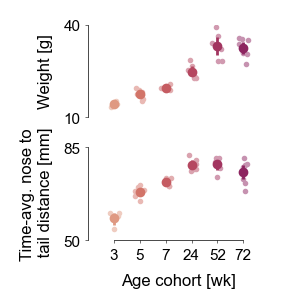

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/weight-ntt-age.pdf')

In [41]:
age_groupby = subj_meta.groupby('Age (wk)')
wt = [age_groupby.get_group(int(a))['Weight (g)'].values for a in ages]
print("Weight increase across dataset:", wt[0].mean(), wt[-1].mean())
print("Weight increase across dataset:", vu.ci(wt[0], n = 1000, absolute=True), vu.ci(wt[-1], n = 1000, absolute=True))

ntt_dist = lambda kpts: (
    la.norm(kpts[:, keypt_ix('nose'), :] - kpts[:, keypt_ix('t_base'), :], axis = -1)
)
ntt = [np.array([ntt_dist(obs_keypts[s]).mean() for s in age_groups[a]]) for a in ages]
print("NTT increase across dataset:", ntt[0].mean(), ntt[-1].mean())
print("Weight increase across dataset:", vu.ci(ntt[0], n = 1000, absolute=True), vu.ci(ntt[-1], n = 1000, absolute=True))


kw = dict(
    error = lambda a, **kw: vu.ci(a, level=0.95, n=1000),
    errorbar_kw = {'elinewidth': 1, 'ms': 2.5},
    points_kw=dict(ms=1),
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 1,
    colors = age_pal,
    offset=False,
    # colors = "k"
)

fig, ax = plt.subplots(2, 1, figsize = (1.4, 1.5), dpi=100)
vu.grouped_stripplot(vu.expand_groups(wt, ages), ax = ax[0], xticks = "", **kw)
ax[0].set_ylabel('Weight [g]')
vu.nticks(ax, 2, x = False)
ax[0].set_ylim(10, 40)
ax[0].set_xticks([])
sns.despine(ax = ax[0], bottom = True)

vu.grouped_stripplot(vu.expand_groups(ntt, ages), ax = ax[1], xticks = ages, **kw)
ax[1].set_ylabel('Time-avg. nose to\n tail distance [mm]')
ax[1].set_xlabel('Age cohort [wk]')
vu.nticks(ax, 2, x = False)
ax[1].set_ylim(50, 85)
sns.despine(ax = ax[1], trim = True)

plotter.finalize(fig, "weight-ntt-age", despine=False)

### b. A few keypoint distances increase with age. All have positive R2



In [448]:
bls = {s: _bone_lengths(obs_keypts[s], arms) for s in sessions}
mean_fl = {s: (bls[s][:, bones_by_short['L forelimb']] + bls[s][:, bones_by_short['R forelimb']]) / 2 for s in sessions}
head = {s: bls[s][:, bones_by_short['head']] for s in sessions}
lo_back = {s: bls[s][:, bones_by_short['hi back']] for s in sessions}

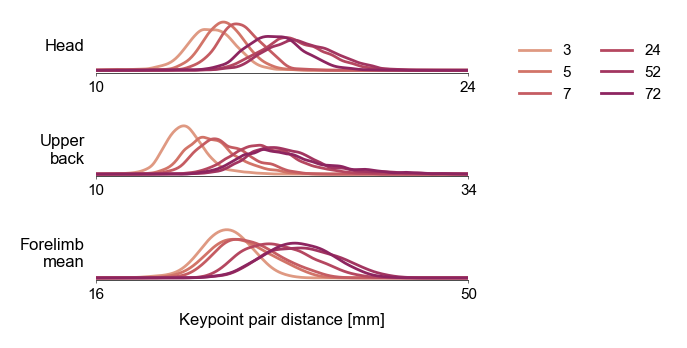

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/b-example_ikds_v_age.pdf')

In [450]:


head_rng = [10, 24]
lo_back_rng = [10, 34]
fl_rng = [16, 50]

fig, ax = plt.subplots(3, 1, figsize = (3.5, 1.7))
for a in ages:
    h = np.concatenate([head[s][::100] for s in age_groups[a]])
    l = np.concatenate([lo_back[s][::100] for s in age_groups[a]])
    f = np.concatenate([mean_fl[s][::100] for s in age_groups[a]])
    hx = np.linspace(*head_rng, 300)
    lx = np.linspace(*lo_back_rng, 300)
    fx = np.linspace(*fl_rng, 300)
    
    
    ax[0].plot(*vu.kde(h, bw = 0.2, eval_x=hx, density=True), lw = 1, color = age_pal[a],
        label = a)
    ax[1].plot(*vu.kde(l, bw = 0.3, eval_x=lx, density=True), lw = 1, color = age_pal[a])
    ax[2].plot(*vu.kde(f, bw = 0.8, eval_x=fx, density=True), lw = 1, color = age_pal[a])
    


vu.nticks(ax, 2)
ax[0].set_xlim(*head_rng)
ax[1].set_xlim(*lo_back_rng)
ax[2].set_xlim(*fl_rng)
for a in ax:
    a.set_yticks([])
    sns.despine(ax = a, trim = True, left = True)

ax[0].set_ylabel('Head', rotation = 0, horizontalalignment = 'right', verticalalignment = 'center')
ax[1].set_ylabel('Upper\nback', rotation = 0, horizontalalignment = 'right', verticalalignment = 'center')
ax[2].set_ylabel('Forelimb\nmean', rotation = 0, horizontalalignment = 'right', verticalalignment = 'center')
ax[2].set_xlabel('Keypoint pair distance [mm]')

vu.legend(ax[0], vu.unique_handles(ax[0]), ncols = 2, bbox_to_anchor = (1.1, 0))


plotter.finalize(fig, "b-example_ikds_v_age", save=True, despine=False,)

In [74]:
r2s = []
mean_r2s = []
for i in range(len(bone_names)):
    x = np.concatenate([
        np.full(len(bls[s]), ages.index(a))
        for a, sl in age_groups.items() for s in sl
    ])
    y = np.concatenate([bls[s][:, i] for a, sl in age_groups.items() for s in sl])
    r2s.append(scipy.stats.pearsonr(x, y).statistic)
    
    x = np.array([np.log(int(a)) for a, sl in age_groups.items() for s in sl])
    y = np.array([np.mean(bls[s][:, i]) for a, sl in age_groups.items() for s in sl])
    mean_r2s.append(np.sqrt(scipy.stats.pearsonr(x, y).statistic))

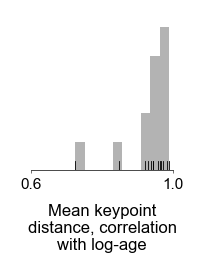

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/b-mean_ikd_age_correlation.pdf')

In [80]:
fig, ax = plt.subplots(1, 1, figsize = (1, 1.3))
ax.hist(mean_r2s, bins = 10, color = '.7')
vu.nticks(ax, 2)
vu.round_limits(ax, precision = 0.2, fixed_vmax = 1, y = False)
for r in mean_r2s:
    ax.axvline(r, color = 'k', lw = 0.3, ymax = 0.06)
ax.set_yticks([])
ax.set_xlabel("Mean keypoint\ndistance, correlation\nwith log-age")
sns.despine(ax = ax, trim = True, left = True)
plotter.finalize(fig, "b-mean_ikd_age_correlation", save=True, despine=False)

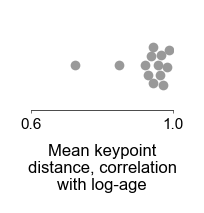

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/b-mean_ikd_age_correlation-swarm.pdf')

In [82]:
fig, ax = plt.subplots(1, 1, figsize = (1, 1.))
sns.swarmplot(x=mean_r2s, y=np.zeros_like(mean_r2s), ax=ax, orient='h', color='.6', size=3.5)
vu.nticks(ax, 2)
vu.round_limits(ax, precision = 0.2, fixed_vmax = 1, y = False)
ax.set_yticks([])
ax.set_xlabel("Mean keypoint\ndistance, correlation\nwith log-age")
sns.despine(ax = ax, trim = True, left = True)
plotter.finalize(fig, "b-mean_ikd_age_correlation-swarm", save=True, despine=False)

### c. Nonuniform scaling of head / torso

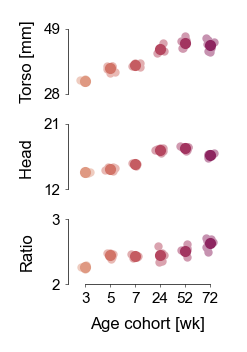

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/torso-head-rto.pdf')

In [100]:
torso_length = lambda kpts: (
    la.norm(kpts[:, keypt_ix('shldr'), :] - kpts[:, keypt_ix('back'), :], axis = -1) +
    la.norm(kpts[:, keypt_ix('back'), :] - kpts[:, keypt_ix('hips'), :], axis = -1)
)
head_length = lambda kpts: la.norm(kpts[:, keypt_ix('nose'), :] - kpts[:, keypt_ix('head'), :], axis = -1)
tl = [np.array([torso_length(obs_keypts[s]).mean() for s in age_groups[a]]) for a in ages]
hl = [np.array([head_length(obs_keypts[s]).mean() for s in age_groups[a]]) for a in ages]
rto = [np.array([(torso_length(obs_keypts[s]) / head_length(obs_keypts[s])).mean() for s in age_groups[a]]) for a in ages]


tl_samp = [vu.ci(l, n = 1000, return_samples=True) for l in [tl[0], tl[-1]]]
hl_samp = [vu.ci(l, n = 1000, return_samples=True) for l in [hl[0], hl[-1]]]

kw = dict(
    error = lambda a, **kw: vu.ci(a, level=0.95, n=1000),
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 0.7,
    colors = age_pal,
    offset=False,
)
fig = plt.figure(figsize = (1.1, 1.7))
ax = fig.add_subplot(311)
vu.grouped_stripplot(vu.expand_groups(tl, ages), ax = ax, xticks = "", **kw)
vu.nticks(ax, 2, x = False)
vu.round_limits(ax, x = False, precision=0.4)
ax.set_xticks([])
sns.despine(ax = ax, bottom = True)
axes = [ax]

ax = fig.add_subplot(312)
vu.grouped_stripplot(vu.expand_groups(hl, ages), ax = ax, xticks = "", **kw)
ax.set_ylim(13, 20)
vu.nticks(ax, 2, x = False)
vu.round_limits(ax, x = False, precision=0.4)
ax.set_xticks([])
sns.despine(ax = ax, bottom = True)
axes.append(ax)

ax = fig.add_subplot(313)
vu.grouped_stripplot(vu.expand_groups(rto, ages), ax = ax, xticks = ages, **kw)
ax.set_xlabel('Age cohort [wk]')
ax.set_ylim(2, 3)
vu.nticks(ax, 2, x = False)
sns.despine(ax = ax, trim = True)
axes.append(ax)

fig.tight_layout()

fig.text(0.01, 0.5, 'Torso [mm]', rotation=90, va='center', ha='center',
    transform=mpl.transforms.blended_transform_factory(fig.transFigure, axes[0].transAxes))
fig.text(0.01, 0.5, 'Head ', rotation=90, va='center', ha='center',
    transform=mpl.transforms.blended_transform_factory(fig.transFigure, axes[1].transAxes))
fig.text(0.01, 0.5, 'Ratio', rotation=90, va='center', ha='center',
    transform=mpl.transforms.blended_transform_factory(fig.transFigure, axes[2].transAxes))

plotter.finalize(fig, "c-torso-head-rto", save=True, despine=False, tight=False)

In [101]:
x = np.round(tl[-1].mean() / tl[0].mean(), 2)
ci = np.round(np.quantile(tl_samp[1] / tl_samp[0], [0.025, 0.975]), 2)
print("Torso length factor:", f"{x} ([{ci[0]}, {ci[1]}])")

x = np.round(hl[-1].mean() / hl[0].mean(), 2)
ci = np.round(np.quantile(hl_samp[1] / hl_samp[0], [0.025, 0.975]), 2)
print("Head length factor:", f"{x} ([{ci[0]}, {ci[1]}])")

Torso length factor: 1.36 ([1.32, 1.39])
Head length factor: 1.17 ([1.16, 1.18])


In [102]:

frames_bl_bhv = {
    k: [
        [_bone_lengths(obs_keypts[s][bhv_labels['masks'][mask_name][s]], arms)
            for s in age_groups[a]]
        for a in ages
    ]
    for k, mask_name in bhv_keys.items()
}
all_bl_bhv = {
    k: [np.array([arr.mean(axis = 0) for arr in l]) for l in frames_bl_bhv[k]]
    for k in bhv_keys
}
frames_bl_total = [
    [_bone_lengths(obs_keypts[s], arms)
        for s in age_groups[a]]
    for a in ages
]
all_bl_total = [np.array([arr.mean(axis = 0) for arr in l]) for l in frames_bl_total]

### S: all bone lengths vs age

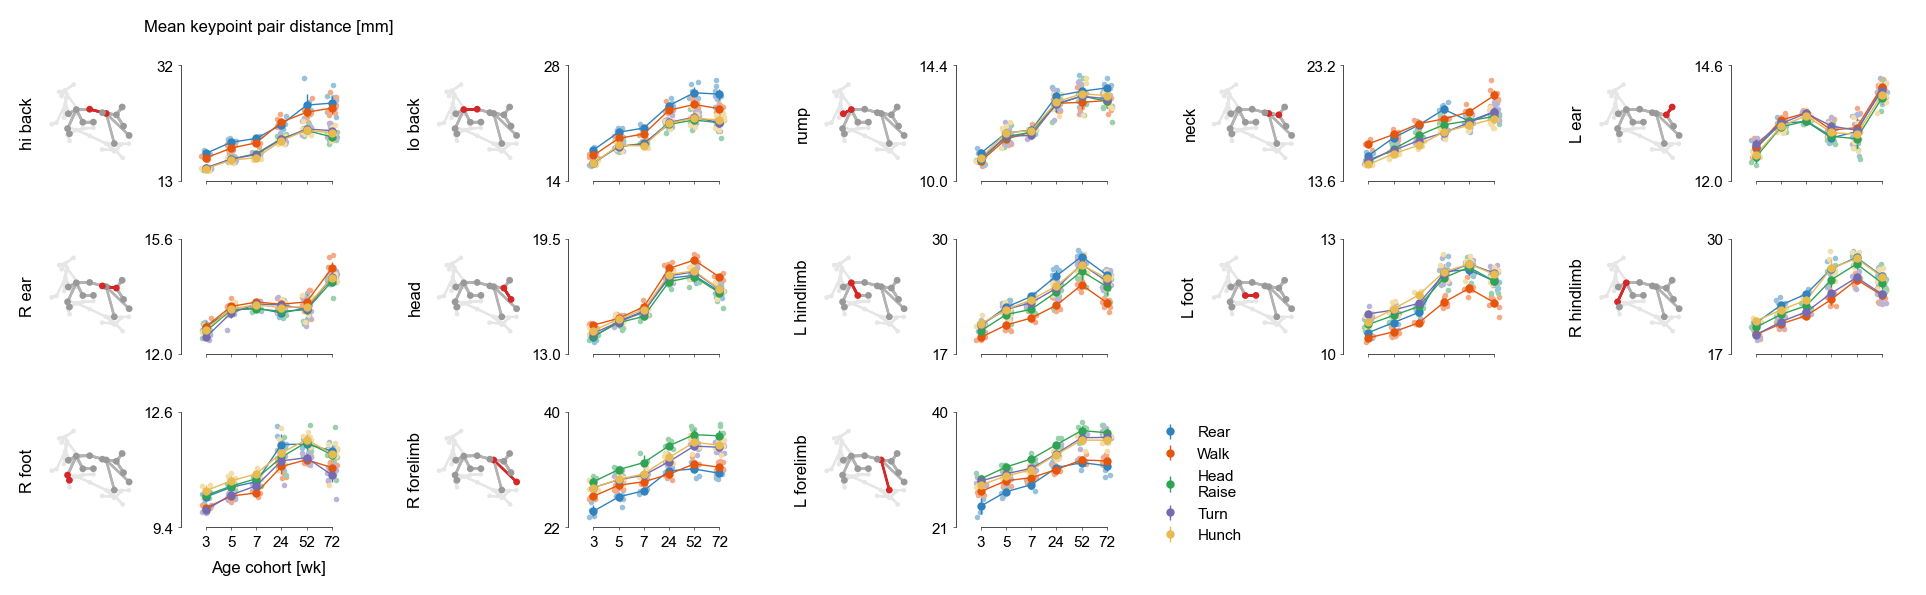

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/S-all-bl-age-bhv.pdf')

In [185]:
ex_sess = '24wk_m0'
ex_frame = 0
ncol = 5
nrow = int(np.ceil(len(bone_names) / ncol))

kw = dict(
    error = lambda a, **kw: vu.ci(a, level=0.95, n=1000),
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 1,
    points_kw = {'ms': 1},
    errorbar_kw = {'elinewidth': 0.5, 'ms': 2},
)

fig = plt.figure(figsize = ((1 + 1 + 0.5) * ncol, 1 * nrow))
gs = plt.GridSpec(nrow, ncol * 3, wspace=0, hspace=0.5, width_ratios=[1, 1, 0.2] * ncol)
row_ix, col_ix = zip(*[(i // ncol, i % ncol) for i in range(len(bone_names))])
ex_ax = [fig.add_subplot(gs[row_ix[i], 3 * col_ix[i]], projection='3d') for i in range(len(bone_names))]
len_ax = [fig.add_subplot(gs[row_ix[i], 3 * col_ix[i] + 1]) for i in range(len(bone_names))]
for i, n in enumerate(bone_names):
    pt_clr = [mpl_col.to_rgba('.6')] * arms.n_kpts
    pt_clr[arms.bones[i, 0]] = mpl_col.to_rgba('C3')
    pt_clr[arms.bones[i, 1]] = mpl_col.to_rgba('C3')
    ln_clr = [mpl_col.to_rgba('.7')] * arms.n_kpts
    ln_clr[arms.bones[i, 0]] = mpl_col.to_rgba('C3')
    
    _plotdrop(
        obs_keypts[ex_sess][ex_frame], ex_ax[i], 
        pt_clr
        , 0.4, 0.6,
        shad_y=False,
        line_colors = ln_clr,
        arms=arms,
        
    )
    ex_ax[i].view_init(30, -45)
    ex_ax[i].text2D(0, 0.5, short_names[n], rotation=90, ha = 'right', va = 'center', transform=ex_ax[i].transAxes)
    if n == 'neck':
        ex_ax[i].view_init(50, -50)
    if n == 'right ear':
        ex_ax[i].view_init(20, -60)
    

    is_bottom = row_ix[i] == nrow - 1
    is_rightmost = col_ix[i] == ncol - 1
    is_top = row_ix[i] == 0
    is_leftmost = col_ix[i] == 0
    is_last = i == len(bone_names) - 1
    vu.grouped_stripplot(
        {bhv_names[k]: [arr[:, i] for arr in all_bl_bhv[k]] for k in bhv_keys},
        ax = len_ax[i],
        xticks = ages if is_bottom else "",
        **{**kw, **{'colors': {bhv_names[k]: bhv_pal[k] for k in bhv_keys}}},
        offset=False,
        labels = True if is_last else None
    )
    for k in bhv_keys:
        len_ax[i].plot([arr[:, i].mean() for arr in all_bl_bhv[k]], '-', lw = 0.5, color=bhv_pal[k])

    vu.nticks(len_ax[i], 2, x = False)
    vu.round_limits(len_ax[i], x = False, precision=1)
    if is_bottom and is_leftmost:
        len_ax[i].set_xlabel('Age cohort [wk]')
    if is_top and is_leftmost:
        len_ax[i].set_title("Mean keypoint pair distance [mm]\n")
    
    sns.despine(ax = len_ax[i], trim = True)
    

plotter.finalize(fig, 'S-all-bl-age-bhv', tight=False)

### h. joint angles during rearing / locomotion across age


In [171]:
all_ja_bhv = {k: [
    np.array([_joint_angles(obs_keypts[s][bhv_masks[k][s]], joint_kp_ixs).mean(axis = 0)
        for s in age_groups[a]])
    for a in ages
] for k in bhv_order}

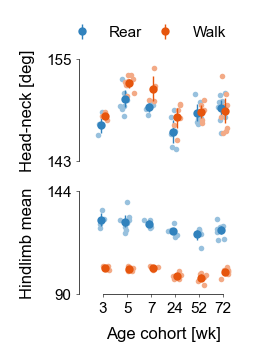

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/h-example-ja-bhv.pdf')

In [465]:
head_ix = joint_names.index('Head-neck')
lh_ix = joint_names.index('L hindlimb')
rh_ix = joint_names.index('R hindlimb')

kw = dict(
    error = lambda a, **kw: vu.ci(a, level=0.95, n=1000),
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 1,
    points_kw = {'ms': 1},
    errorbar_kw = {'elinewidth': 0.5, 'ms': 2},
)
kws = dict(
    **{**kw, **{'colors': bhv_pal}},
    labels = bhv_names,
    legend = False
)

fig, ax = plt.subplots(2, 1, figsize = (1.3, 1.6))

vu.grouped_stripplot(
    {"rear": [arr[:, head_ix] for arr in all_ja_bhv['rear']],
    "loco": [arr[:, head_ix] for arr in all_ja_bhv['loco']]},
    ax = ax[0],
    xticks = "",
    **kws,
)
vu.grouped_stripplot(
    {"rear": [(arr[:, lh_ix] + arr[:, rh_ix]) / 2 for arr in all_ja_bhv['rear']],
    "loco": [(arr[:, lh_ix] + arr[:, rh_ix]) / 2 for arr in all_ja_bhv['loco']]},
    ax = ax[1],
    xticks = ages,
    **kws,
)

for a in ax:
    vu.nticks(a, 2, x = False)
    vu.round_limits(a, x = False, precision=0.9)
ax[0].set_xticks([])
sns.despine(ax = ax[0], bottom = True)
sns.despine(ax = ax[1], trim = True)
ax[0].set_ylabel('Head-neck [deg]')
ax[1].set_ylabel('Hindlimb mean')
    
ax[1].set_xlabel('Age cohort [wk]')
fig.tight_layout()
vu.legend(ax[0], loc='lower center', ncols=2, columnspacing=0.5, bbox_to_anchor=(0.4, 1.05))

plotter.finalize(fig, 'h-example-ja-bhv', save = True, despine=False, tight=False)

### S. all JA's by age and behavior

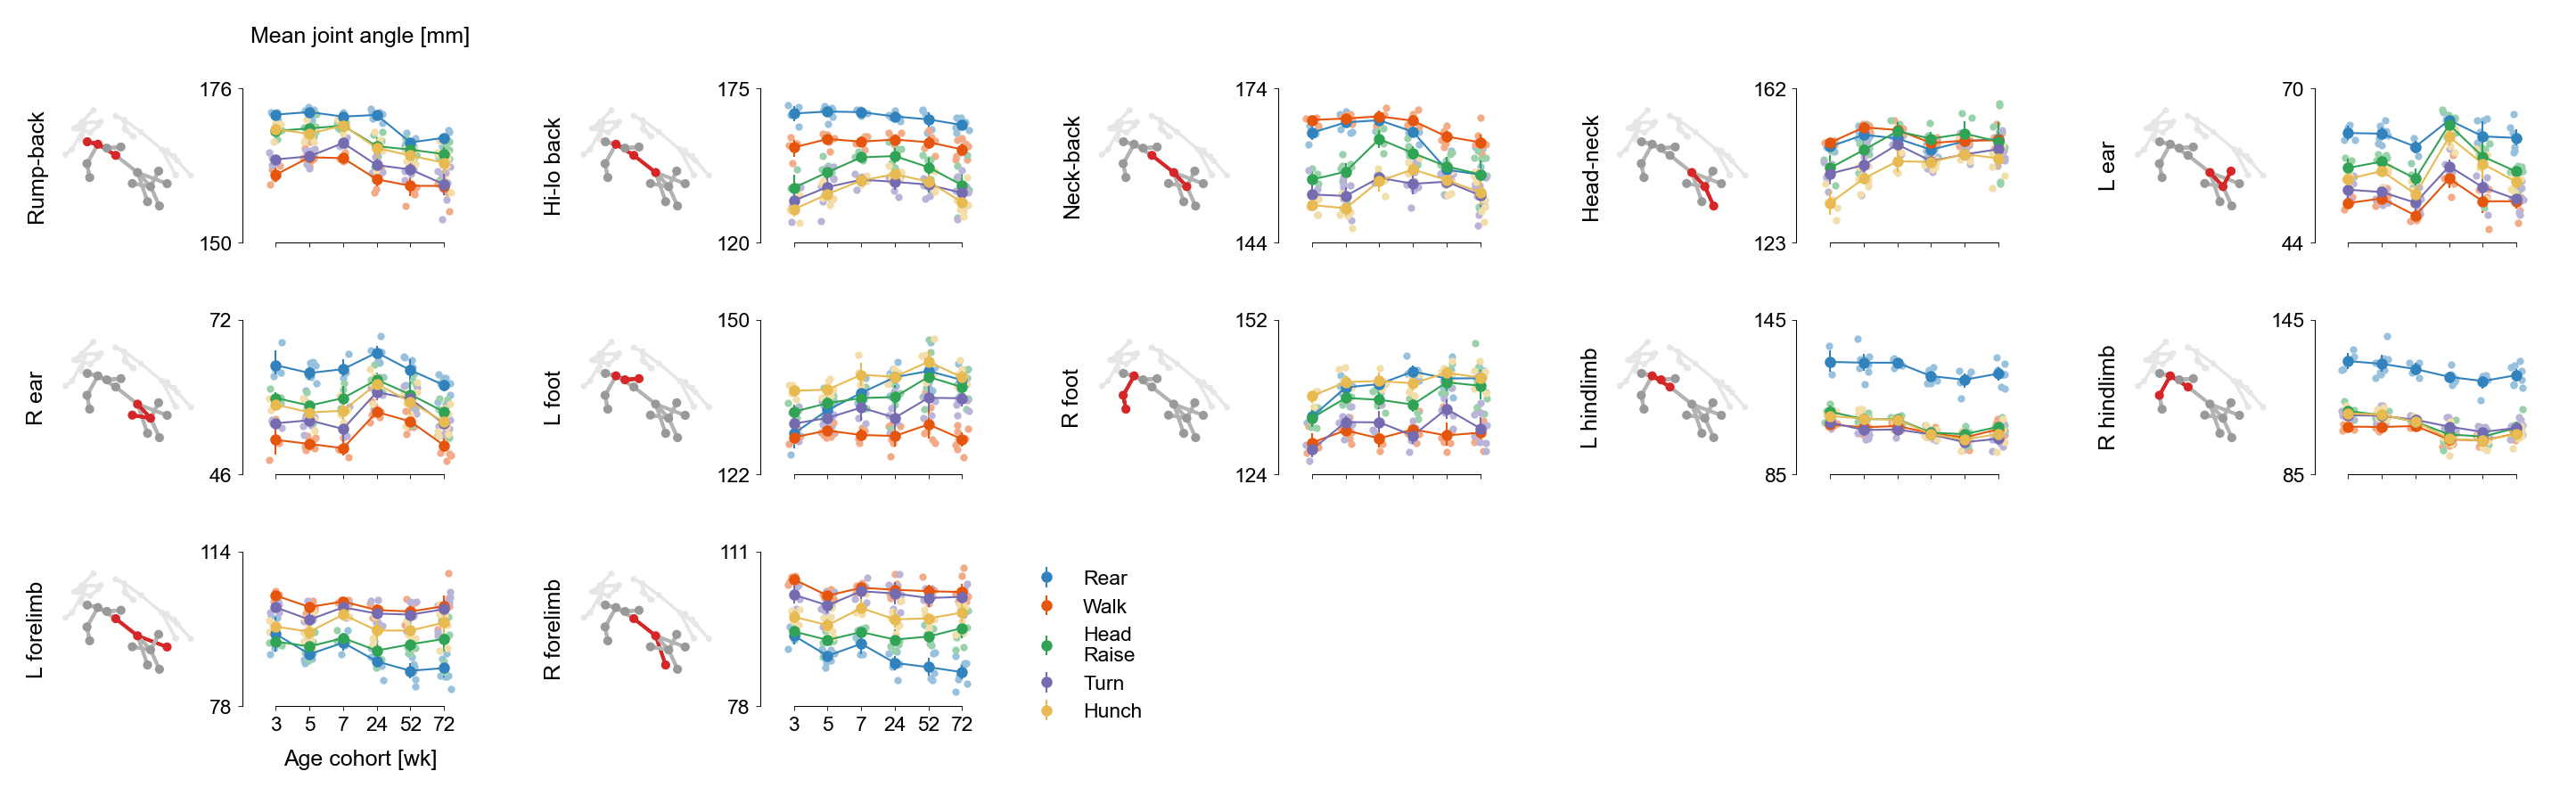

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/S-all-ja-age-bhv.pdf')

In [183]:
ex_sess = '24wk_m0'
ex_frame = 0
ncol = 5
nrow = int(np.ceil(len(joint_names) / ncol))

kw = dict(
    error = lambda a, **kw: vu.ci(a, level=0.95, n=1000),
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 1,
    points_kw = {'ms': 1},
    errorbar_kw = {'elinewidth': 0.5, 'ms': 2},
)

fig = plt.figure(figsize = ((1 + 1 + 0.5) * ncol, 1 * nrow), dpi=150)
gs = plt.GridSpec(nrow, ncol * 3, wspace=0, hspace=0.5, width_ratios=[1, 1, 0.2] * ncol)
row_ix, col_ix = zip(*[(i // ncol, i % ncol) for i in range(len(joint_names))])
ex_ax = [fig.add_subplot(gs[row_ix[i], 3 * col_ix[i]], projection='3d') for i in range(len(joint_names))]
len_ax = [fig.add_subplot(gs[row_ix[i], 3 * col_ix[i] + 1]) for i in range(len(joint_names))]

for i, n in enumerate(joint_names):
    pt_clr = np.array([mpl_col.to_rgba('.6')] * arms.n_kpts)
    pt_clr[joint_kp_ixs[i, :]] = np.array(mpl_col.to_rgba('C3'))[None]
    ln_clr = np.array([mpl_col.to_rgba('.7')] * arms.n_kpts)
    jt_bones = [j for j, b in enumerate(arms.bones) if b[0] in joint_kp_ixs[i, :] and b[1] in joint_kp_ixs[i, :]]
    ln_clr[arms.bones[jt_bones[0], 0]] = mpl_col.to_rgba('C3')
    ln_clr[arms.bones[jt_bones[1], 0]] = mpl_col.to_rgba('C3')
    
    _plotdrop(
        obs_keypts[ex_sess][ex_frame], ex_ax[i], 
        pt_clr
        , 0.4, 0.6,
        # shad_y=False,
        shad_z=False,
        line_colors = ln_clr,
        arms=arms,
    )
    ex_ax[i].view_init(70, -45)
    ex_ax[i].text2D(0, 0.5, n, rotation=90, ha = 'right', va = 'center', transform=ex_ax[i].transAxes)
    

    is_bottom = row_ix[i] == nrow - 1
    is_rightmost = col_ix[i] == ncol - 1
    is_top = row_ix[i] == 0
    is_leftmost = col_ix[i] == 0
    is_last = i == len(joint_names) - 1
    vu.grouped_stripplot(
        {bhv_names[k]: [arr[:, i] for arr in all_ja_bhv[k]] for k in bhv_keys},
        ax = len_ax[i],
        xticks = ages if is_bottom else "",
        **{**kw, **{'colors': {bhv_names[k]: bhv_pal[k] for k in bhv_keys}}},
        offset=False,
        labels = True if is_last else None
    )
    for k in bhv_keys:
        len_ax[i].plot([arr[:, i].mean() for arr in all_ja_bhv[k]], '-', lw = 0.5, color=bhv_pal[k])

    vu.nticks(len_ax[i], 2, x = False)
    vu.round_limits(len_ax[i], x = False, precision=1)
    if is_bottom and is_leftmost:
        len_ax[i].set_xlabel('Age cohort [wk]')
    if is_top and is_leftmost:
        len_ax[i].set_title("Mean joint angle [mm]\n")
    
    sns.despine(ax = len_ax[i], trim = True)
    

plotter.finalize(fig, 'S-all-ja-age-bhv', tight=False)

### d. Many nonuniform IKD relationships


In [216]:
coefs_bhv = {k: np.zeros([len(bone_names)]) for k in bhv_order}
coefs_tot = np.zeros([len(bone_names)])
coefs_bhv_ci = {k: np.zeros([len(bone_names), 2]) for k in bhv_order}
coefs_tot_ci = np.zeros([len(bone_names), 2])
group_order = ages

frames_bl_bhv = {
    k: [_bone_lengths(obs_keypts[s][bhv_labels['masks'][mask_name][s]], arms)
        for s in sessions]
    for k, mask_name in bhv_keys.items()
}
frames_bl_total = [_bone_lengths(obs_keypts[s], arms) for s in sessions]
session_ages = [int(re.search(r"(\d+)wk", s).group(1)) for s in sessions]


rng = np.random.default_rng(4871)
nboot = 10
cov = lambda x, y: (x * y).mean(axis=-1) - x.mean(axis=-1) * y.mean(axis=-1)
coef = lambda a, b: cov(a, b) / cov(a, a)


for r in trange(len(bone_ix_order)):
    r_ix = bone_ix_order[r]

    logage = np.log(session_ages)

    for k in bhv_order:
        rto_bhv = np.array([
            arr[:, r_ix].mean() for arr in frames_bl_bhv[k]
        ])
        coefs_bhv[k][r] = coef(logage, rto_bhv)
        boot_samp = np.zeros([nboot])
        for j in range(nboot):
            shuf = rng.choice(len(rto_bhv), len(rto_bhv), replace = True)
            boot_samp[j] = coef(logage[shuf], rto_bhv[shuf])
        coefs_bhv_ci[k][r] = np.quantile(boot_samp, [0.025, 0.975])

    rto = np.array([
        arr[:, r_ix].mean() for arr in frames_bl_total
    ])
    coefs_tot[r] = coef(logage, rto)
    boot_samp = np.zeros([nboot])
    for j in range(nboot):
        shuf = rng.choice(len(rto), len(rto), replace = True)
        boot_samp[j] = coef(logage[shuf], rto[shuf])
    coefs_tot_ci[r] = np.quantile(boot_samp, [0.025, 0.975])
    

100%|██████████| 13/13 [00:00<00:00, 56.91it/s]


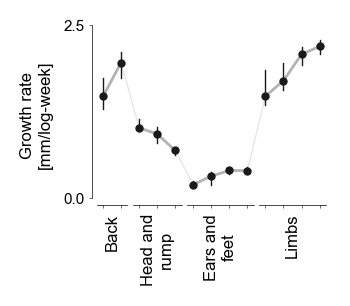

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/d-relative-growth-rates.pdf')

In [250]:
fig, ax = plt.subplots(1, 1, figsize=(1.7, 1.5))
ax.plot(coefs_tot, "-", color=".9", lw=0.5)
for bg in bone_groups:
    x = np.arange(bg[0], bg[1] + 1)
    ax.plot(x, coefs_tot[bg[0] : bg[1] + 1], "-", color=".7", lw=1)
    ax.plot(x, coefs_tot[bg[0] : bg[1] + 1], "o", color=colors.neutral, ms=2)
    for i in x:
        ax.plot([i, i], coefs_tot_ci[i], '-', color=colors.neutral, lw=0.5)



ax.set_xticks(np.arange(len(bone_names)))
ax.set_xticklabels(bone_names, rotation=70, horizontalalignment="right")
ax.set_yticks([0, 2.5])
ax.set_ylim(-0.1, 2.5)
sns.despine(ax=ax, trim=True)
fig.tight_layout()

# Bone groups x axis
ax.set_xticks(np.arange(len(bone_names)))
ax.set_xticklabels([""] * len(bone_names))
sns.despine(ax=ax, trim=True, bottom=True)

ymin, _ = ax.get_ylim()
for bg, n in zip(bone_groups, bone_group_names):
    ax.add_artist(
        mpl.lines.Line2D(
            [bg[0] - 0.35, bg[1] + 0.35],
            [ymin, ymin],
            color="k",
            lw=0.25,
            clip_on=False,
        )
    )
    ax.add_artist(
        mpl.text.Text(
            (bg[0] + bg[1]) / 2,
            -0.05,
            n,
            ha="center",
            va="top",
            clip_on=False,
            fontsize=6,
            rotation=90,
            transform=mpl.transforms.blended_transform_factory(
                ax.transData, ax.transAxes
            ),
        )
    )
for x in range(0, len(bone_names)):
    ax.add_artist(
        mpl.lines.Line2D(
            [x, x],
            [-1e-2, -1e-2],
            color="k",
            lw=0.25,
            clip_on=False,
            solid_capstyle="butt",
        )
    )


ax.set_ylabel("Growth rate\n[mm/log-week]")

plotter.finalize(fig, "d-relative-growth-rates", despine=False)

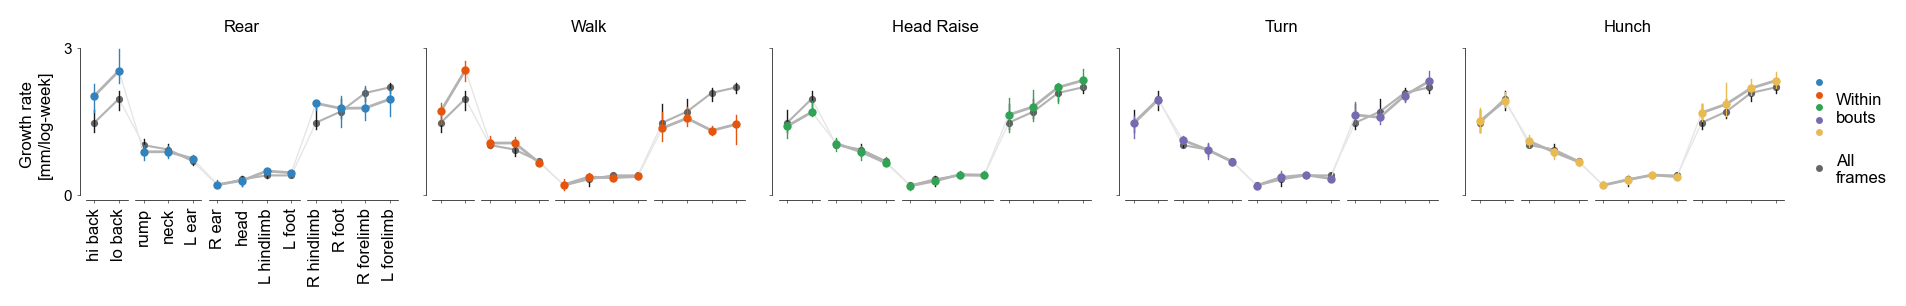

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/S-relative-growth-rates-bhv.pdf')

In [249]:
fig, axes = plt.subplots(1, len(bhv_keys), figsize = (9, 1.5), sharey=True)
for i, (ax, bhv) in enumerate(zip(axes, bhv_keys)):
    
    ax.plot(coefs_tot, "-", color=".9", lw=0.5)
    for bg in bone_groups:
        x = np.arange(bg[0], bg[1] + 1)
        ax.plot(x, coefs_tot[bg[0] : bg[1] + 1], "-", color=".7", lw=0.75)
        ax.plot(x, coefs_tot[bg[0] : bg[1] + 1], "o", color='.4', ms=1.6)
        for j in x:
            ax.plot([j, j], coefs_tot_ci[j], '-', color=colors.neutral, lw=0.5)

    
    ax.plot(coefs_bhv[bhv], "-", color=".9", lw=0.5)
    for bg in bone_groups:
        x = np.arange(bg[0], bg[1] + 1)
        ax.plot(x, coefs_bhv[bhv][bg[0] : bg[1] + 1], '-', color = '.7', lw = 1)
        ax.plot(x, coefs_bhv[bhv][bg[0] : bg[1] + 1], 'o', color = bhv_pal[bhv], ms = 2)
        for j in x:
            ax.plot([j, j], coefs_bhv_ci[bhv][j], '-', color=bhv_pal[bhv], lw=0.5)


    sns.despine(ax = ax, trim = True, bottom = True)
    ax.set_title(bhv_names[bhv].replace('\n', ' '))

    ax.set_xticks(np.arange(len(bone_names)))
    ax.set_xticklabels(bone_names, rotation=70, horizontalalignment="right")
    ax.set_yticks([0, 3])
    ax.set_ylim(-0.1, 3)
    sns.despine(ax=ax, trim=True)
    fig.tight_layout()

    # Bone groups x axis
    ax.set_xticks(np.arange(len(bone_names)))
    ax.set_xticklabels([""] * len(bone_names))
    sns.despine(ax=ax, trim=True, bottom=True)

    ymin, _ = ax.get_ylim()
    for bg, n in zip(bone_groups, bone_group_names):
        ax.add_artist(
            mpl.lines.Line2D(
                [bg[0] - 0.35, bg[1] + 0.35],
                [ymin, ymin],
                color="k",
                lw=0.25,
                clip_on=False,
            )
        )
        if i == 0:
            for j in np.arange(bg[0], bg[1] + 1):
                ax.add_artist(
                    mpl.text.Text(
                        j,
                        -0.05,
                        short_names[bone_names[j]],
                        ha="center",
                        va="top",
                        clip_on=False,
                        fontsize=6,
                        rotation=90,
                        transform=mpl.transforms.blended_transform_factory(
                            ax.transData, ax.transAxes
                        ),
                    )
                )
            # ax.add_artist(
            #     mpl.text.Text(
            #         (bg[0] + bg[1]) / 2,
            #         -0.05,
            #         n,
            #         ha="center",
            #         va="top",
            #         clip_on=False,
            #         fontsize=6,
            #         rotation=90,
            #         transform=mpl.transforms.blended_transform_factory(
            #             ax.transData, ax.transAxes
            #         ),
            #     )
            # )
    for x in range(0, len(bone_names)):
        ax.add_artist(
            mpl.lines.Line2D(
                [x, x],
                [-1e-2, -1e-2],
                color="k",
                lw=0.25,
                clip_on=False,
                solid_capstyle="butt",
            )
        )



axes[0].set_ylabel("Growth rate\n[mm/log-week]")
fig.tight_layout()

handles = [axes[-1].plot([np.nan], [np.nan], 'o', ms = 2.5, mew = 0, color = bhv_pal[k], label = " ")[0] for k in bhv_order]
handles_tot = axes[-1].plot([np.nan], [np.nan], 'o', ms = 2.5, mew = 0, color = '.4', label = " ")

leg = vu.legend(axes[-1], (handles, " " * len(bhv_order)), loc='center left', bbox_to_anchor = (1, 0.6), labelspacing=-0.1)
axes[-1].text(1.14, 0.6, "Within\nbouts", ha='left', va='center', transform=axes[-1].transAxes)
vu.legend(axes[-1], (handles_tot, [" "]), loc='center left', bbox_to_anchor = (1, 0.2), labelspacing=0.)
axes[-1].text(1.14, 0.2, "All\nframes", ha='left', va='center', transform=axes[-1].transAxes)
axes[-1].add_artist(leg)


plotter.finalize(fig, 'S-relative-growth-rates-bhv', despine = False, tight=False)


### g. Example frame for joint angle

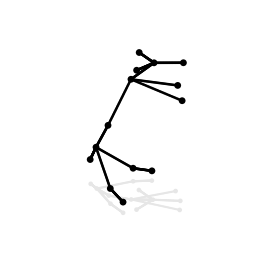

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/g-ja-pose-example.pdf')

In [248]:
fig, ax = plt.subplots(1, 1, figsize = (1.3, 1.8), subplot_kw={"projection":'3d'})
# kws = dict(
#     armature = arms,
#     elev = 30, rot = -80,
#     colors = [colors.neutral] * 14,
#     line_colors = [colors.neutral] * 14,
#     bone_n = 40,
#     point_size = 4,
#     line_size = 0.7,
#     boundary = True
# )

plotdrop(obs_keypts['52wk_m0'][800], ax, 'k', 0.4, 0.6, arms=arms, shady=False, shadx=False)
ax.view_init(30, -70)



plotter.finalize(fig, 'g-ja-pose-example', save = True)

### e. Uniform scaling; reduction of IKD variance

In [14]:
ntt_dist = lambda kpts: (
    la.norm(kpts[:, keypt_ix('nose'), :] - kpts[:, keypt_ix('t_base'), :], axis = -1)
)
scales = {s: ntt_dist(obs_keypts[s]).mean(axis = 0) for s in sessions}
ref_size = scales['3wk_m0']
scaled = {s: obs_keypts[s] / scales[s] * ref_size for s in sessions}


In [15]:
### save scales for later use
jl.dump(scales, '../../../../data_explore/data/v6_f1.1-uniform-scales.p')

['../../../../data_explore/data/v6_f1.1-uniform-scales.p']

In [16]:
ex_yng = '3wk_m0'
ex_old = '52wk_m0'
age_yng = '3'
age_old = '52'
frame_yng = 702
frame_old = la.norm(scaled[ex_yng][None, frame_yng] - scaled[ex_old], axis = -1).mean(axis = -1).argsort(0)[5]

In [17]:
frame_old

2049

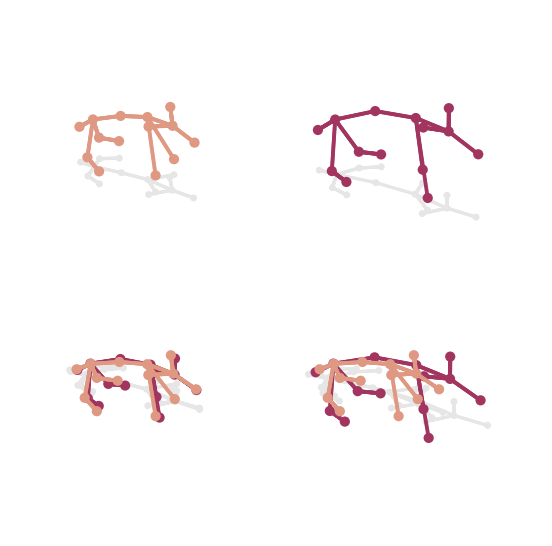

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/e-uniform-scale-overlay.pdf')

In [455]:

fig = plt.figure(figsize = (1.8, 1.8), dpi=150)
gs = plt.GridSpec(2, 2, wspace=0, hspace=0)
row0 = [fig.add_subplot(gs[0, i], projection='3d') for i in range(2)]
row1_shad = [fig.add_subplot(gs[1, i], projection='3d') for i in range(2)]
row1_back = [fig.add_subplot(gs[1, i], projection='3d') for i in range(2)]
row1_frnt = [fig.add_subplot(gs[1, i], projection='3d') for i in range(2)]


for a in row0[1:] + row1_shad + row1_back + row1_frnt:
    a.sharex(row0[0])
    a.sharey(row0[0])
    a.sharez(row0[0])

plotdrop(scaled[ex_yng][frame_yng], row1_frnt[0], age_pal[age_yng], 0.4, 0.6, arms=arms, shady=False, shadx=False, dropax=row1_shad[0])
plotdrop(scaled[ex_old][frame_old], row1_back[0], age_pal[age_old], 0.4, 0.6, arms=arms, shady=False, shadx=False, dropax=row1_shad[0])
plotdrop(obs_keypts[ex_yng][frame_yng], row1_frnt[1], age_pal[age_yng], 0.4, 0.6, arms=arms, shady=False, shadx=False, dropax=row1_shad[1])
plotdrop(obs_keypts[ex_old][frame_old], row1_back[1], age_pal[age_old], 0.4, 0.6, arms=arms, shady=False, shadx=False, dropax=row1_shad[1])
plotdrop(obs_keypts[ex_yng][frame_yng], row0[0], age_pal[age_yng], 0.4, 0.6, arms=arms, shady=False, shadx=False, dropax=row0[0])
plotdrop(obs_keypts[ex_old][frame_old], row0[1], age_pal[age_old], 0.4, 0.6, arms=arms, shady=False, shadx=False, dropax=row0[1])

# plot_mouse_3d(obs_keypts[ex_yng][frame_yng], ax[0, 0], **kws(age_yng))
# plot_mouse_3d(scaled[ex_yng][frame_yng], ax[1, 0], **kws(age_yng))
# plot_mouse_3d(scaled[ex_old][frame_old], ax[1, 0], **kws(age_old))
# plot_mouse_3d(obs_keypts[ex_yng][frame_yng], ax[1, 1], **kws(age_yng))
# plot_mouse_3d(obs_keypts[ex_old][frame_old], ax[1, 1], **kws(age_old))
# plot_mouse_3d(obs_keypts[ex_old][frame_old], ax[0, 1], **kws(age_old))



plotter.finalize(fig, 'e-uniform-scale-overlay', save = True, despine = False)

In [304]:
bls_scl = {s: _bone_lengths(    scaled[s], arms) for s in sessions}
bls_obs = {s: _bone_lengths(obs_keypts[s], arms) for s in sessions}
mean_fl = {s: (bls_scl[s][:, bones_by_short['L forelimb']] + bls_scl[s][:, bones_by_short['R forelimb']]) / 2 for s in sessions}
head = {s: bls_scl[s][:, bones_by_short['head']] for s in sessions}
lo_back = {s: bls_scl[s][:, bones_by_short['hi back']] for s in sessions}

mean_iqd = lambda x, mean_axis = (0,): scipy.stats.iqr([a.mean(axis = mean_axis) for a in x], axis = 0)
mean_iqd_scl = mean_iqd(bls_scl.values())
mean_iqd_obs = mean_iqd(bls_obs.values())

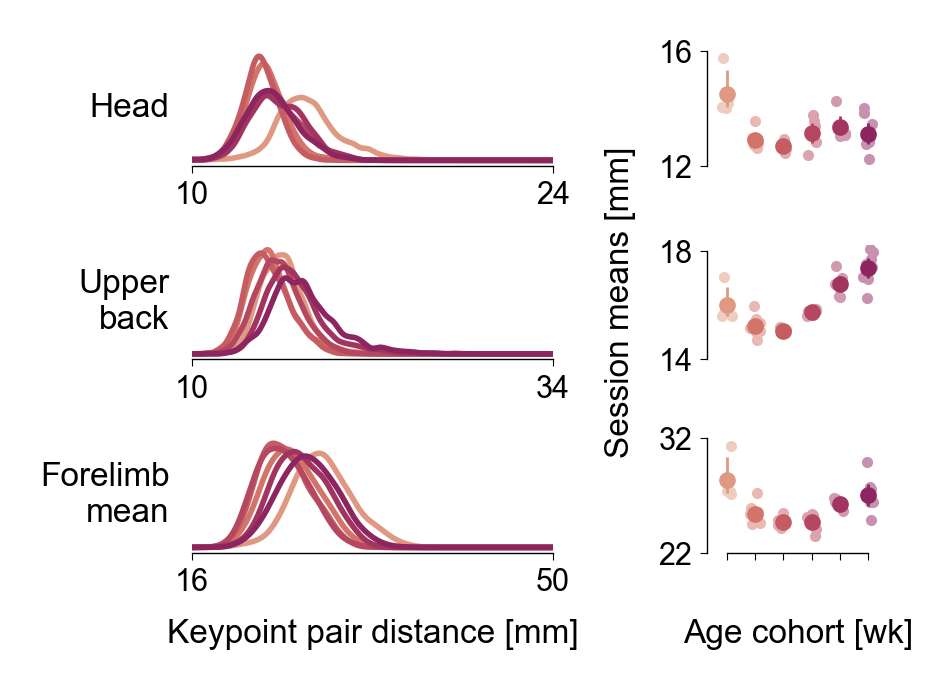

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/e-uniform-scale-ikds.pdf')

In [329]:
kw = dict(
    error = lambda a, **kw: vu.ci(a, level=0.95, n=1000),
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 1,
    points_kw = {'ms': 1},
    errorbar_kw = {'elinewidth': 0.5, 'ms': 2},
    offset=False
)


head_rng = [10, 24]
lo_back_rng = [10, 34]
fl_rng = [16, 50]

fig, axes = plt.subplots(3, 2, figsize = (2.3, 1.7), dpi=200, width_ratios=[1, 0.5])
ax = axes[:, 0]
ax_means = axes[:, 1]
age_order = sorted(ages, key = lambda x: int(x))

for i, a in enumerate(age_order):
    sl = age_groups[a]
    h = np.concatenate([head[s][::100] for s in sl])
    l = np.concatenate([lo_back[s][::100] for s in sl])
    f = np.concatenate([mean_fl[s][::100] for s in sl])
    hx = np.linspace(*head_rng, 300)
    lx = np.linspace(*lo_back_rng, 300)
    fx = np.linspace(*fl_rng, 300)
    
    ax[0].plot(*vu.kde(h, bw = 0.2, eval_x=hx, density=True), lw = 1, color = age_pal[a])
    ax[1].plot(*vu.kde(l, bw = 0.3, eval_x=lx, density=True), lw = 1, color = age_pal[a])
    ax[2].plot(*vu.kde(f, bw = 0.8, eval_x=fx, density=True), lw = 1, color = age_pal[a])

    vu.grouped_stripplot(
        [np.array([head[s].mean() for s in sl])], x = [i], ax = ax_means[0],
        colors = age_pal[a], **kw)
    vu.grouped_stripplot(
        [np.array([lo_back[s].mean() for s in sl])], x = [i], ax = ax_means[1],
        colors = age_pal[a], **kw)
    vu.grouped_stripplot(
        [np.array([mean_fl[s].mean() for s in sl])], x = [i], ax = ax_means[2],
        colors = age_pal[a], **kw)

vu.nticks(ax, 2)
ax[0].set_xlim(*head_rng)
ax[1].set_xlim(*lo_back_rng)
ax[2].set_xlim(*fl_rng)
for a in ax:
    a.set_yticks([])
    sns.despine(ax = a, trim = True, left = True)

ax_means[0].set_yticks([12, 16])
ax_means[1].set_yticks([14, 18])
ax_means[2].set_yticks([22, 32])
for a in ax_means[:-1]:
    a.set_xlim(-0.7, len(age_order) - 0.3)
    a.set_xticks([])
    sns.despine(ax = a, trim = True, bottom=True)
ax_means[-1].set_xlim(-0.7, len(age_order) - 0.3)
ax_means[-1].set_xticks(np.arange(len(age_order)))
ax_means[-1].set_xticklabels([" "] * len(age_order))
ax_means[-1].set_xlabel('Age cohort [wk]')
sns.despine(ax = ax_means[-1], trim = True)
ax_means[1].set_ylabel("Session means [mm]")



ax[0].set_ylabel('Head', rotation = 0, horizontalalignment = 'right', verticalalignment = 'center')
ax[1].set_ylabel('Upper\nback', rotation = 0, horizontalalignment = 'right', verticalalignment = 'center')
ax[2].set_ylabel('Forelimb\nmean', rotation = 0, horizontalalignment = 'right', verticalalignment = 'center')
ax[2].set_xlabel('Keypoint pair distance [mm]')

plotter.finalize(fig, "e-uniform-scale-ikds", save=True, despine=False)

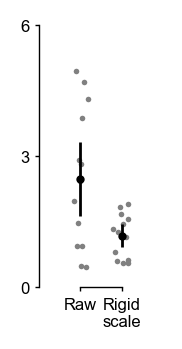

In [367]:
fig, ax = plt.subplots(1, 1, figsize = (0.8, 1.7))

kw = dict(
    error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    # errorbar_kw = {'elinewidth': 0.5, 'ms': 2},
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 1,
    colors = "k"
)
viz.util.grouped_stripplot(
    [mean_iqd_obs, mean_iqd_scl],
    ax = ax,
    xticks = ["Raw", "Rigid\nscale"],
    **kw
)

viz.util.nticks(ax, 3, x = False)
viz.util.round_limits(ax, x = False, precision=0.7, fixed_vmin = 0)
sns.despine(ax = ax, trim = True)

../../plots/notebook/panels/v4/f1.1_ikd-ja/mean-iqr-reduction.pdf


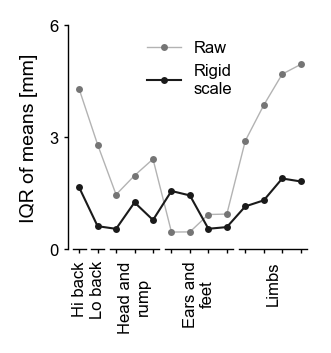

In [417]:
fig, ax = plt.subplots(1, 1, figsize = (1.7, 1.8))
ax.plot(mean_iqd_obs[bone_ix_order], '-o', markerfacecolor = viz.util.lighten(colors.neutral, 0.4), color = colors.semisubtle, lw = 0.5, ms = 2.5, label = "Raw")
ax.plot(mean_iqd_scl[bone_ix_order], '-o', color = colors.neutral, lw = 0.75, ms = 2.5, label = "Rigid\nscale")

viz.util.nticks(ax, 3, x = False)
viz.util.round_limits(ax, x = False, precision=0.5, fixed_vmin = 0)
ax.set_xticks(np.arange(len(bone_order)))
ax.set_xticklabels([""] * len(bone_order))
# ax.set_xticklabels(bone_name_order, rotation = 70, horizontalalignment = 'right')
sns.despine(ax = ax, trim = True, bottom = True)

for bg, n in zip(bone_groups, bone_group_names):
    ax.add_artist(mpl.lines.Line2D(
        [bg[0] - 0.35, bg[1] + 0.35], [0, 0],
        color = 'k', lw = 0.5, clip_on = False,
    ))
    ax.add_artist(mpl.text.Text(
        (bg[0] + bg[1]) / 2, -0.3, n, ha = 'center', va = 'top',
        clip_on = False, fontsize = 6, rotation = 90,
        # transform = mpl.transforms.blended_transform_factory(ax.transData, fig.transFigure),
    ))
for x in range(0, len(bone_order)):
    ax.add_artist(mpl.lines.Line2D(
        [x, x], [-1e-2, -1e-2],
        color = 'k', lw = 0.25, clip_on = False, solid_capstyle = 'butt',))
ax.set_ylabel("IQR of means [mm]")

viz.util.legend(ax, loc = 'upper center', bbox_to_anchor = None)

fig.tight_layout()

plotter.finalize(fig, 'mean-iqr-reduction', save = True, transparent = True, despine = False)


### f. linear classifiers after rigid scaling

In [421]:
# Canonicalized and naive-scale-aligned
sessions = list(obs_keypts.keys())

feats = calculate_feat_scaled_kp_normed(scaled, arms, subsample=50)

groups = set(re.search(r"(\d+)wk", s).group(1) for s in sessions)
groups = {k: [s for s in sessions if re.search(r"(\d+)wk", s).group(1) == k] for k in groups}
# indivs = {i: [s for s in sessions if re.search(r"_m(\d+)", s).group(1) == i] for i in "01"}

ref_age = "3"
tgt_ages = sorted([a for a in groups.keys() if a != ref_age], key = int)
scores = calc_all_scores(feats, groups, ref_age, tgt_ages, n_iter = 4)

100%|██████████| 21/21 [00:51<00:00,  2.44s/it]


/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


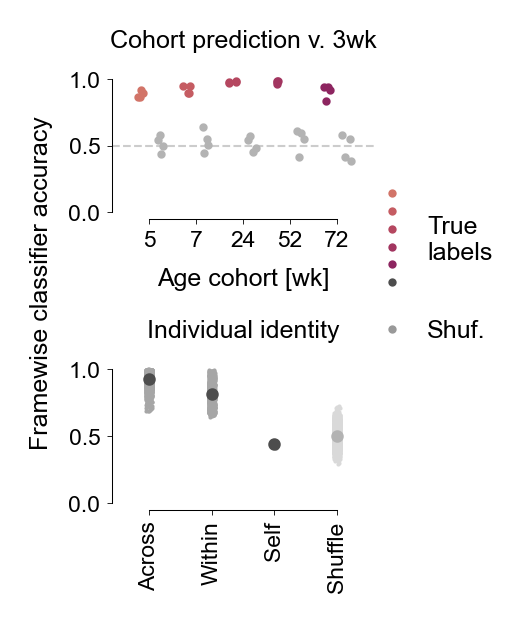

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/f-linear-classif.pdf')

In [426]:
fig, ax = plt.subplots(2, 1, figsize=(1.2, 1.8), dpi = 150)

classif_strip_points(ax[0], tgt_ages, scores[0], [age_pal[a] for a in tgt_ages], -0.2, point_ms=1)
classif_strip_points(ax[0], tgt_ages, scores[1], ['.7'] * len(tgt_ages), 0.2, point_ms=1)
classif_strip(ax[1], range(4), scores[2], ['.3', '.3', '.3', '.7'], 0, point_ms=1)


ax[0].set_xticks(np.arange(len(tgt_ages)))
ax[0].set_xticklabels(tgt_ages)
ax[0].set_xlim(-0.8, len(tgt_ages) - 1 + 0.8)
ax[1].set_xticks(np.arange(4))
ax[1].set_xlim(-0.6, 3 + 0.6)

ax[0].axhline(0.5, ls = '--', lw = 0.5, color = '.8', zorder = -3)
for a in ax.ravel():
    a.set_ylim(-0.05, 1.05)
    sns.despine(ax = a, trim = True)
ax[0].set_xticks(range(len(tgt_ages)))
ax[0].set_xticklabels(tgt_ages)


ax[0].set_xlabel("Age cohort [wk]")
ax[0].set_title(f"Cohort prediction v. {ref_age}wk")
ax[1].set_title("Individual identity")
fig.tight_layout()
ax[1].set_xticklabels(["Across", "Within", "Self", "Shuffle"], rotation = 90, fontsize = 5.5)
fig.text(0.0, 0.48, "Framewise classifier accuracy", ha = 'center', va = 'center', rotation = 90)


handles = [ax[0].plot([np.nan], [np.nan], 'o', ms = 2, mew = 0, color = c, label = " ")[0] for c in [age_pal[a] for a in tgt_ages] + ['.3']]
handles_shuf = ax[0].plot([np.nan], [np.nan], 'o', ms = 2, mew = 0, color = '.6', label = " ")
leg = vu.legend(ax[0], (handles, " " * len(handles)), loc='center left', bbox_to_anchor = (0.9, -0.14), labelspacing=-.1)
ax[0].text(1.2, -0.14, "True\nlabels", ha='left', va='center', transform=ax[0].transAxes)
vu.legend(ax[0], (handles_shuf, [" "]), loc='center left', bbox_to_anchor = (0.9, -0.76), labelspacing=0.)
ax[0].text(1.2, -0.76, "Shuf.", ha='left', va='center', transform=ax[0].transAxes)
ax[0].add_artist(leg)


plotter.finalize(fig, "f-linear-classif", despine = False, tight=False)

#### S. Classification after rigid scaling within behaviors

In [14]:
# Canonicalized and naive-scale-aligned
sessions = list(obs_keypts.keys())

groups = set(re.search(r"(\d+)wk", s).group(1) for s in sessions)
groups = {k: [s for s in sessions if re.search(r"(\d+)wk", s).group(1) == k] for k in groups}
# indivs = {i: [s for s in sessions if re.search(r"_m(\d+)", s).group(1) == i] for i in "01"}

ref_age = "3"
tgt_ages = sorted([a for a in groups.keys() if a != ref_age], key = int)
scores_bhv = {
    k: calc_all_scores(
        calculate_feat_scaled_kp_normed({s: a[bhv_masks[k][s]] for s, a in obs_keypts.items()}, arms, subsample=50),
        groups, ref_age, tgt_ages, n_iter = 4)
    for k in bhv_order
}

100%|██████████| 21/21 [00:14<00:00,  1.47it/s]


/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of f

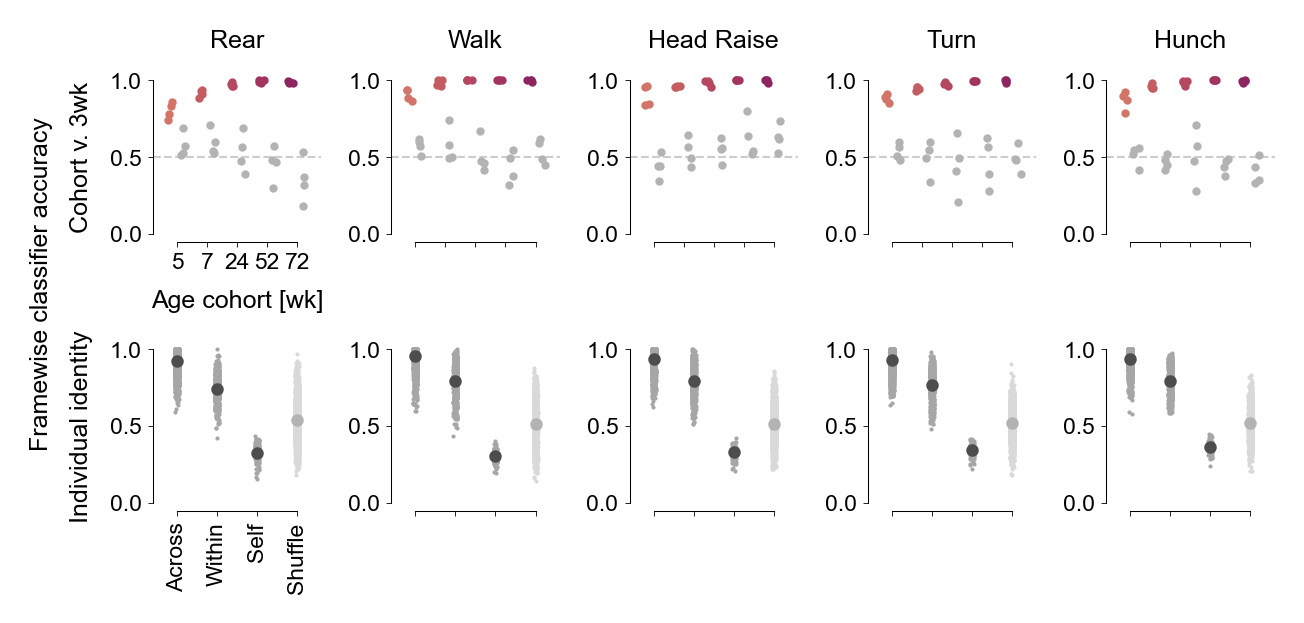

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/S-keypt-linear-classif.pdf')

In [18]:
fig, axes = plt.subplots(2, len(bhv_order), figsize=(4.2, 1.8), dpi = 150)

for k, ax in zip(bhv_order, axes.T):
    classif_strip_points(ax[0], tgt_ages, scores_bhv[k][0], [age_pal[a] for a in tgt_ages], -0.2, point_ms=1)
    classif_strip_points(ax[0], tgt_ages, scores_bhv[k][1], ['.7'] * len(tgt_ages), 0.2, point_ms=1)
    # allway_scores = [scores[2][i] for i in [0, 2, 1, 3]]
    classif_strip(ax[1], range(4), scores_bhv[k][2], ['.3', '.3', '.3', '.7'], 0, point_ms=1)


    ax[0].set_xticks(np.arange(len(tgt_ages)))
    ax[0].set_xticklabels(tgt_ages)
    ax[0].set_xlim(-0.8, len(tgt_ages) - 1 + 0.8)
    ax[1].set_xticks(np.arange(4))
    ax[1].set_xlim(-0.6, 3 + 0.6)

    ax[0].axhline(0.5, ls = '--', lw = 0.5, color = '.8', zorder = -3)
    for a in ax.ravel():
        a.set_ylim(-0.05, 1.05)
        sns.despine(ax = a, trim = True)
    ax[0].set_xticks(range(len(tgt_ages)))
    ax[0].set_xticklabels([''] * len(tgt_ages))

    ax[0].set_title(bhv_names[k].replace('\n', ' '))

axes[0, 0].set_xticklabels(tgt_ages)
axes[0, 0].set_xlabel("Age cohort [wk]")
axes[0, 0].set_ylabel(f"Cohort v. {ref_age}wk")
axes[1, 0].set_ylabel("Individual identity")
fig.tight_layout()
axes[1, 0].set_xticklabels(["Across", "Within", "Self", "Shuffle"], rotation = 90, fontsize = 5.5)

ax = axes[:, -1]

fig.text(0.0, 0.48, "Framewise classifier accuracy", ha = 'center', va = 'center', rotation = 90)


# handles = [ax[0].plot([np.nan], [np.nan], 'o', ms = 2, mew = 0, color = c, label = " ")[0] for c in [age_pal[a] for a in tgt_ages] + ['.3']]
# handles_shuf = ax[0].plot([np.nan], [np.nan], 'o', ms = 2, mew = 0, color = '.6', label = " ")
# leg = vu.legend(ax[0], (handles, " " * len(handles)), loc='center left', bbox_to_anchor = (0.9, -0.14), labelspacing=-.1)
# ax[0].text(1.2, -0.14, "True\nlabels", ha='left', va='center', transform=ax[0].transAxes)
# vu.legend(ax[0], (handles_shuf, [" "]), loc='center left', bbox_to_anchor = (0.9, -0.76), labelspacing=0.)
# ax[0].text(1.2, -0.76, "Shuf.", ha='left', va='center', transform=ax[0].transAxes)
# ax[0].add_artist(leg)


plotter.finalize(fig, "S-keypt-linear-classif", despine = False, tight=False)

#### i. linear classification by joint angles

In [431]:
# Canonicalized and naive-scale-aligned
sessions = list(obs_keypts.keys())

obs_ja = {s: _joint_angles(obs_keypts[s], joint_kp_ixs) for s in sessions}
feats = calculate_feat_scaled_kp_normed(obs_ja, arms, subsample=50, mode='angles')

groups = set(re.search(r"(\d+)wk", s).group(1) for s in sessions)
groups = {k: [s for s in sessions if re.search(r"(\d+)wk", s).group(1) == k] for k in groups}
# indivs = {i: [s for s in sessions if re.search(r"_m(\d+)", s).group(1) == i] for i in "01"}

ref_age = "3"
tgt_ages = sorted([a for a in groups.keys() if a != ref_age], key = int)
scores = calc_all_scores(feats, groups, ref_age, tgt_ages, n_iter = 10)

100%|██████████| 21/21 [00:15<00:00,  1.33it/s]


/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


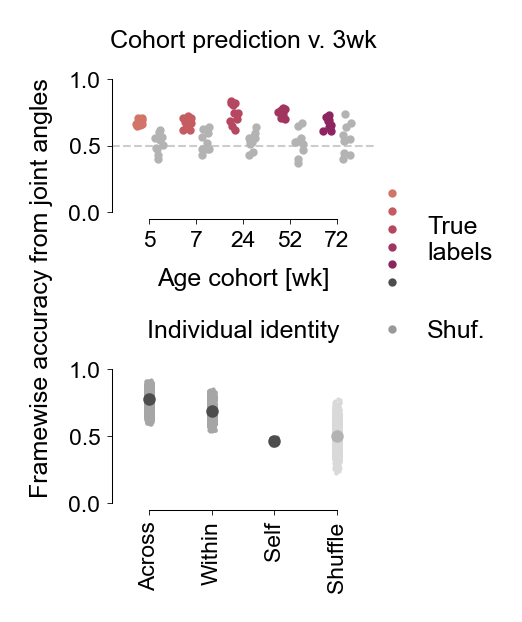

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/i-linear-classif.pdf')

In [432]:
fig, ax = plt.subplots(2, 1, figsize=(1.2, 1.8), dpi = 150)

classif_strip_points(ax[0], tgt_ages, scores[0], [age_pal[a] for a in tgt_ages], -0.2, point_ms=1)
classif_strip_points(ax[0], tgt_ages, scores[1], ['.7'] * len(tgt_ages), 0.2, point_ms=1)
# allway_scores = [scores[2][i] for i in [0, 2, 1, 3]]
classif_strip(ax[1], range(4), scores[2], ['.3', '.3', '.3', '.7'], 0., point_ms=1)


ax[0].set_xticks(np.arange(len(tgt_ages)))
ax[0].set_xticklabels(tgt_ages)
ax[0].set_xlim(-0.8, len(tgt_ages) - 1 + 0.8)
ax[1].set_xticks(np.arange(4))
ax[1].set_xlim(-0.6, 3 + 0.6)

ax[0].axhline(0.5, ls = '--', lw = 0.5, color = '.8', zorder = -3)
for a in ax.ravel():
    a.set_ylim(-0.05, 1.05)
    sns.despine(ax = a, trim = True)
ax[0].set_xticks(range(len(tgt_ages)))
ax[0].set_xticklabels(tgt_ages)


ax[0].set_xlabel("Age cohort [wk]")
ax[0].set_title(f"Cohort prediction v. {ref_age}wk")
ax[1].set_title("Individual identity")
fig.tight_layout()
ax[1].set_xticklabels(["Across", "Within", "Self", "Shuffle"], rotation = 90, fontsize = 5.5)
fig.text(0.0, 0.47, "Framewise accuracy from joint angles", ha = 'center', va = 'center', rotation = 90)


handles = [ax[0].plot([np.nan], [np.nan], 'o', ms = 2, mew = 0, color = c, label = " ")[0] for c in [age_pal[a] for a in tgt_ages] + ['.3']]
handles_shuf = ax[0].plot([np.nan], [np.nan], 'o', ms = 2, mew = 0, color = '.6', label = " ")
leg = vu.legend(ax[0], (handles, " " * len(handles)), loc='center left', bbox_to_anchor = (0.9, -0.14), labelspacing=-.1)
ax[0].text(1.2, -0.14, "True\nlabels", ha='left', va='center', transform=ax[0].transAxes)
vu.legend(ax[0], (handles_shuf, [" "]), loc='center left', bbox_to_anchor = (0.9, -0.76), labelspacing=0.)
ax[0].text(1.2, -0.76, "Shuf.", ha='left', va='center', transform=ax[0].transAxes)
ax[0].add_artist(leg)


plotter.finalize(fig, "i-linear-classif", despine = False, tight=False)

### S. Classification by joint angles within behavior

In [446]:
# Canonicalized and naive-scale-aligned
sessions = list(obs_keypts.keys())

obs_ja = {s: _joint_angles(obs_keypts[s], joint_kp_ixs) for s in sessions}

groups = set(re.search(r"(\d+)wk", s).group(1) for s in sessions)
groups = {k: [s for s in sessions if re.search(r"(\d+)wk", s).group(1) == k] for k in groups}
# indivs = {i: [s for s in sessions if re.search(r"_m(\d+)", s).group(1) == i] for i in "01"}

ref_age = "3"
tgt_ages = sorted([a for a in groups.keys() if a != ref_age], key = int)
scores_bhv = {
    k: calc_all_scores(
        calculate_feat_scaled_kp_normed({s: a[bhv_masks[k][s]] for s, a in obs_ja.items()}, arms, subsample=50, mode='angles'),
        groups, ref_age, tgt_ages, n_iter = 10)
    for k in bhv_order
}

100%|██████████| 21/21 [00:15<00:00,  1.37it/s]


/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of f

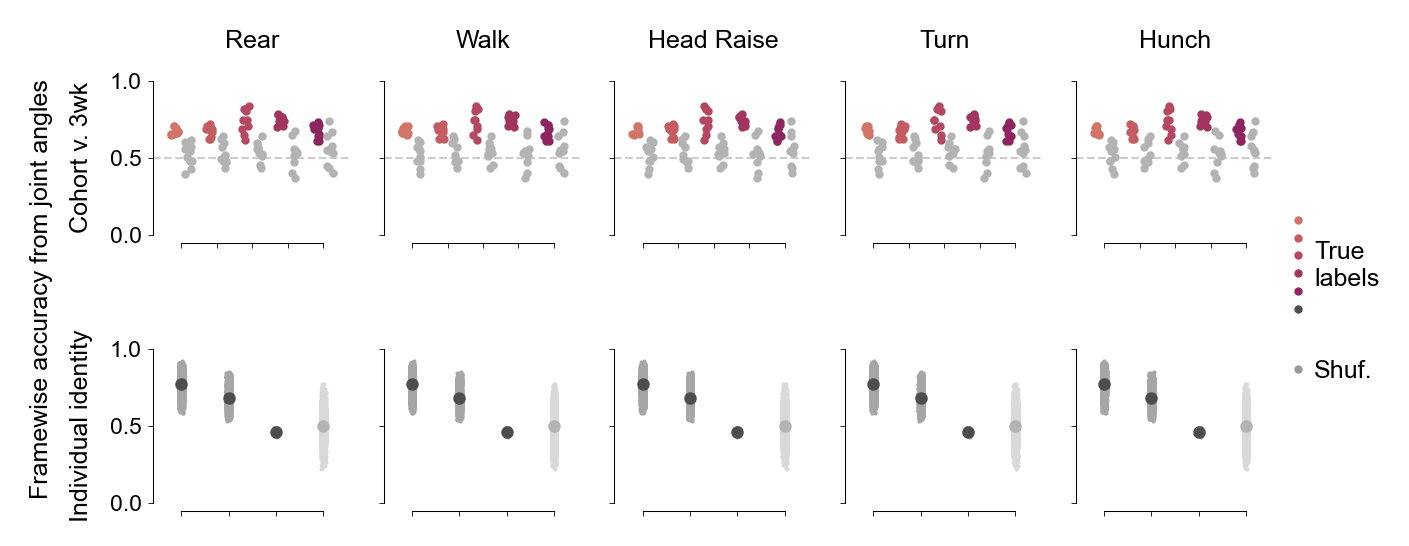

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f1.1_ikd-ja/S-keypt-linear-classif.pdf')

In [447]:
fig, axes = plt.subplots(2, len(bhv_order), figsize=(4.2, 1.8), dpi = 150, sharey='row')

for k, ax in zip(bhv_order, axes.T):
    classif_strip_points(ax[0], tgt_ages, scores[0], [age_pal[a] for a in tgt_ages], -0.2, point_ms=1)
    classif_strip_points(ax[0], tgt_ages, scores[1], ['.7'] * len(tgt_ages), 0.2, point_ms=1)
    # allway_scores = [scores[2][i] for i in [0, 2, 1, 3]]
    classif_strip(ax[1], range(4), scores[2], ['.3', '.3', '.3', '.7'], 0, point_ms=1)


    ax[0].set_xticks(np.arange(len(tgt_ages)))
    ax[0].set_xticklabels(tgt_ages)
    ax[0].set_xlim(-0.8, len(tgt_ages) - 1 + 0.8)
    ax[1].set_xticks(np.arange(4))
    ax[1].set_xlim(-0.6, 3 + 0.6)

    ax[0].axhline(0.5, ls = '--', lw = 0.5, color = '.8', zorder = -3)
    for a in ax.ravel():
        a.set_ylim(-0.05, 1.05)
        sns.despine(ax = a, trim = True)
    ax[0].set_xticks(range(len(tgt_ages)))
    ax[0].set_xticklabels([''] * len(tgt_ages))

    ax[0].set_title(bhv_names[k].replace('\n', ' '))


axes[0, 0].set_xticklabels(" " * len(tgt_ages))
axes[0, 0].set_xlabel(" ")
axes[0, 0].set_ylabel(f"Cohort v. {ref_age}wk")
axes[1, 0].set_ylabel("Individual identity")
fig.tight_layout()
# axes[1, 0].set_xticklabels(["Across", "Within", "Self", "Shuffle"], rotation = 90, fontsize = 5.5)

ax = axes[:, -1]

fig.text(0.0, 0.47, "Framewise accuracy from joint angles", ha = 'center', va = 'center', rotation = 90)


handles = [ax[0].plot([np.nan], [np.nan], 'o', ms = 2, mew = 0, color = c, label = " ")[0] for c in [age_pal[a] for a in tgt_ages] + ['.3']]
handles_shuf = ax[0].plot([np.nan], [np.nan], 'o', ms = 2, mew = 0, color = '.6', label = " ")
leg = vu.legend(ax[0], (handles, " " * len(handles)), loc='center left', bbox_to_anchor = (0.9, -0.14), labelspacing=-.1)
ax[0].text(1.2, -0.14, "True\nlabels", ha='left', va='center', transform=ax[0].transAxes)
vu.legend(ax[0], (handles_shuf, [" "]), loc='center left', bbox_to_anchor = (0.9, -0.76), labelspacing=0.)
ax[0].text(1.2, -0.76, "Shuf.", ha='left', va='center', transform=ax[0].transAxes)
ax[0].add_artist(leg)


plotter.finalize(fig, "S-ja-linear-classif", despine = False, tight=False)

### a. example images

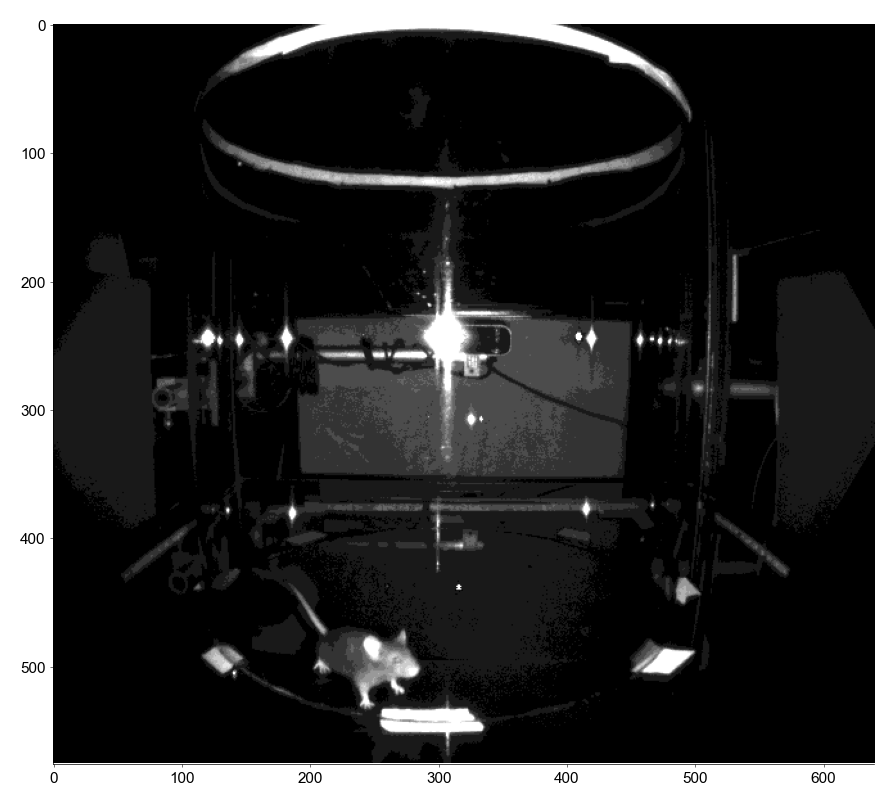

In [78]:
import imageio.v3 as iio
f = Path('../../../../multisize_frames/10_11_22_3wk_m0.702.side2.png')
n = 10
x = iio.imread(f)
x = np.clip(x[:, ::-1] * (255 / n), 0, 255).astype('uint8')
plt.imshow(x)
plt.show()
iio.imwrite(str(f).replace('.png', '.contrast.png'), x)

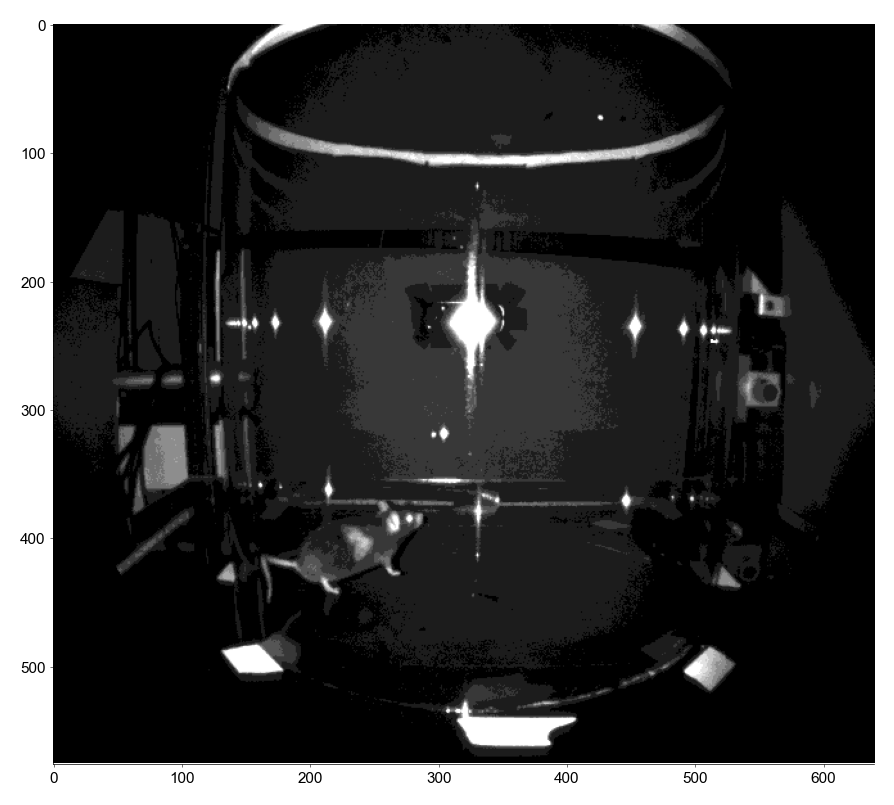

In [73]:
import imageio.v3 as iio
f = Path('../../../../multisize_frames/11_03_22_52wk_m0.2049.side3.png')
n = 9
x = iio.imread(f)
x = np.clip(x * (255 / n), 0, 255).astype('uint8')
plt.imshow(x)
plt.show()
iio.imwrite(str(f).replace('.png', '.contrast.png'), x)

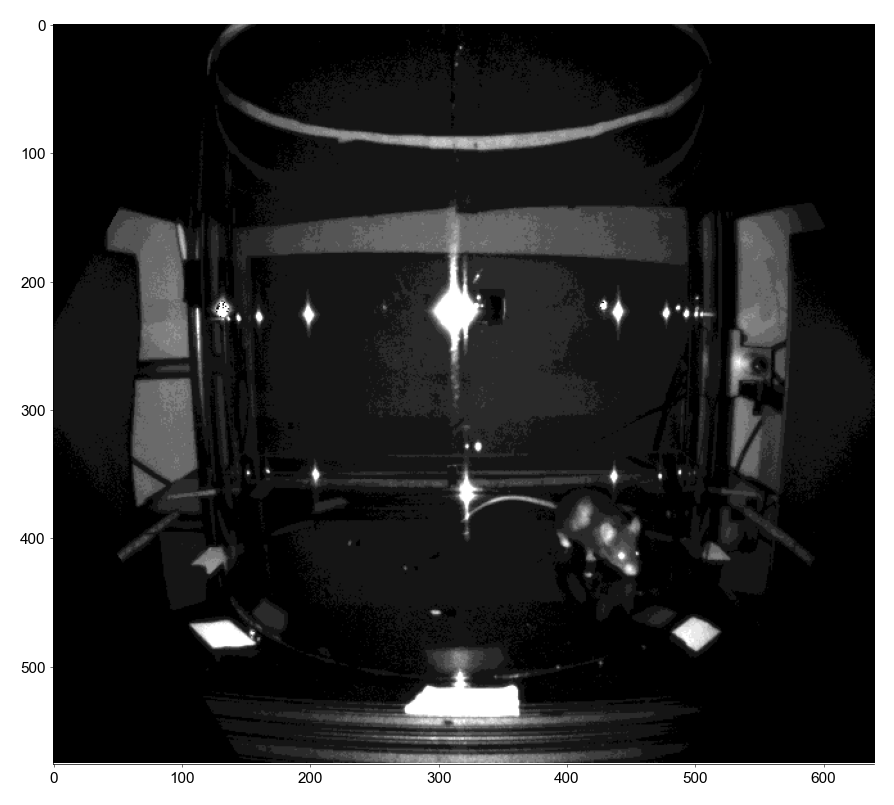

In [69]:

f = Path('../../../../multisize_frames/11_03_22_52wk_m0.10031.side4.png')
n = 12
x = iio.imread(f)
x = np.clip(x * (255 / n), 0, 255).astype('uint8')
plt.imshow(x)
plt.show()
iio.imwrite(str(f).replace('.png', '.contrast.png'), x)